In [3]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/LINCS_small_molecules.tsv")

lincs_df = pd.read_csv(DATA_PATH, sep="\t")

print(lincs_df.shape)
display(lincs_df.head())
print(lincs_df.columns.tolist())

(34418, 8)


,Unnamed: 0,pert_name,target,moa,canonical_smiles,inchi_key,compound_aliases,sig_count
0,BRD-K60230970,MG-132,PSMB1,Proteasome inhibitor,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(...,TZYWCYJVHRLUCT-VABKMULXSA-N,-,8257
1,BRD-K50691590,bortezomib,"PSMB2, PSMB5, PSMB1","Proteasome inhibitor, NFKB pathway inhibitor",CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...,RFGAQTOFZHCFHG-NVXWUHKLSA-N,-,6776
2,BRD-K81418486,vorinostat,"HDAC8, HDAC2, HDAC3, HDAC6, HDAC1",HDAC inhibitor,ONC(=O)CCCCCCC(=O)Nc1ccccc1,WAEXFXRVDQXREF-UHFFFAOYSA-N,-,3244
3,BRD-K49865102,PD-0325901,MAP2K1,"MEK inhibitor, Protein kinase inhibitor, MAP k...",OC[C@@H](O)CONC(=O)c1ccc(F)c(F)c1Nc1ccc(I)cc1F,SUDAHWBOROXANE-SECBINFHSA-N,-,1796
4,BRD-K21680192,mitoxantrone,TOP2A,Topoisomerase inhibitor,OCCNCCNc1ccc(NCCNCCO)c2C(=O)c3c(O)ccc(O)c3C(=O...,KKZJGLLVHKMTCM-UHFFFAOYSA-N,-,1740


['Unnamed: 0', 'pert_name', 'target', 'moa', 'canonical_smiles', 'inchi_key', 'compound_aliases', 'sig_count']


In [4]:
# Keep only rows with usable chemical structures
lincs_clean = lincs_df.dropna(subset=["canonical_smiles"]).copy()

# Remove blank strings just in case
lincs_clean = lincs_clean[
    lincs_clean["canonical_smiles"].str.strip() != ""
].copy()

# Deduplicate molecules by canonical SMILES
lincs_unique = lincs_clean.drop_duplicates(
    subset="canonical_smiles"
).reset_index(drop=True)

print(f"Original rows: {len(lincs_df):,}")
print(f"Rows with SMILES: {len(lincs_clean):,}")
print(f"Unique molecules: {len(lincs_unique):,}")

display(
    lincs_unique[
        ["pert_name", "canonical_smiles", "inchi_key", "moa", "sig_count"]
    ].head()
)

Original rows: 34,418
Rows with SMILES: 34,418
Unique molecules: 28,576


,pert_name,canonical_smiles,inchi_key,moa,sig_count
0,MG-132,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(...,TZYWCYJVHRLUCT-VABKMULXSA-N,Proteasome inhibitor,8257
1,bortezomib,CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...,RFGAQTOFZHCFHG-NVXWUHKLSA-N,"Proteasome inhibitor, NFKB pathway inhibitor",6776
2,vorinostat,ONC(=O)CCCCCCC(=O)Nc1ccccc1,WAEXFXRVDQXREF-UHFFFAOYSA-N,HDAC inhibitor,3244
3,PD-0325901,OC[C@@H](O)CONC(=O)c1ccc(F)c(F)c1Nc1ccc(I)cc1F,SUDAHWBOROXANE-SECBINFHSA-N,"MEK inhibitor, Protein kinase inhibitor, MAP k...",1796
4,mitoxantrone,OCCNCCNc1ccc(NCCNCCO)c2C(=O)c3c(O)ccc(O)c3C(=O...,KKZJGLLVHKMTCM-UHFFFAOYSA-N,Topoisomerase inhibitor,1740


In [5]:
from rdkit import Chem

def is_valid_smiles(smiles):
    return Chem.MolFromSmiles(smiles) is not None

lincs_unique["valid_smiles"] = lincs_unique["canonical_smiles"].apply(is_valid_smiles)

print(lincs_unique["valid_smiles"].value_counts())

lincs_valid = lincs_unique[
    lincs_unique["valid_smiles"]
].reset_index(drop=True)

print(f"Valid molecules for fingerprinting: {len(lincs_valid):,}")

[11:02:05] SMILES Parse Error: syntax error while parsing: -
[11:02:05] SMILES Parse Error: check for mistakes around position 1:
[11:02:05] -
[11:02:05] ^
[11:02:05] SMILES Parse Error: Failed parsing SMILES '-' for input: '-'
[11:02:05] SMILES Parse Error: syntax error while parsing: restricted
[11:02:05] SMILES Parse Error: check for mistakes around position 1:
[11:02:05] restricted
[11:02:05] ^
[11:02:05] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'


valid_smiles
True     28574
False        2
Name: count, dtype: int64
Valid molecules for fingerprinting: 28,574


In [6]:
import numpy as np
from rdkit.Chem import AllChem, DataStructs

RADIUS = 2
N_BITS = 2048

def smiles_to_morgan(smiles, radius=RADIUS, n_bits=N_BITS):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=n_bits
    )
    
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

morgan_fingerprints = np.vstack(
    lincs_valid["canonical_smiles"].apply(smiles_to_morgan).to_numpy()
)

print("Fingerprint matrix shape:", morgan_fingerprints.shape)
print("Data type:", morgan_fingerprints.dtype)
print("Example fingerprint:", morgan_fingerprints[0, :20])

[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerator
[11:02:11] DEPRECATION WARNING: please use MorganGenerat

Fingerprint matrix shape: (28574, 2048)
Data type: float32
Example fingerprint: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
from pathlib import Path

Path("../data").mkdir(exist_ok=True)

np.save(
    "../data/lincs_morgan_fingerprints_2048.npy",
    morgan_fingerprints
)

lincs_valid.to_csv(
    "../data/lincs_small_molecules_valid_unique.tsv",
    sep="\t",
    index=False
)

print("Saved fingerprint matrix and cleaned metadata.")

Saved fingerprint matrix and cleaned metadata.


In [7]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# 70% train, 30% temporary holdout
X_train, X_temp = train_test_split(
    morgan_fingerprints,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Split remaining 30% equally:
# 15% validation, 15% test overall
X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (20001, 2048)
Validation shape: (4286, 2048)
Test shape: (4287, 2048)


In [8]:
BATCH_SIZE = 128

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 157
Validation batches: 34
Test batches: 34


In [9]:
import torch.nn as nn

INPUT_DIM = 2048
LATENT_DIM = 15

class MorganAutoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

In [10]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MorganAutoencoder().to(DEVICE)

print("Using device:", DEVICE)
print(model)

Using device: cpu
MorganAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=15, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2048, bias=True)
    (5): Sigmoid()
  )
)


In [10]:
import torch.optim as optim

LEARNING_RATE = 1e-3
NUM_EPOCHS = 50

criterion = nn.BCELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Epochs:", NUM_EPOCHS)

Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epochs: 50


In [11]:
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    # ---- Training ----
    model.train()
    running_train_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(DEVICE)

        optimizer.zero_grad()

        reconstructed, _ = model(batch)
        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(DEVICE)

            reconstructed, _ = model(batch)
            loss = criterion(reconstructed, batch)

            running_val_loss += loss.item() * batch.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Save best model based on validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/lincs_morgan_autoencoder_best.pt"
        )

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.5f} | "
        f"Val Loss: {epoch_val_loss:.5f}"
    )

print(f"\nBest validation loss: {best_val_loss:.5f}")
print(f"Best epoch: {best_epoch}")
print("Saved best model to: ../models/lincs_morgan_autoencoder_best.pt")

Epoch 01/50 | Train Loss: 0.12514 | Val Loss: 0.07993
Epoch 02/50 | Train Loss: 0.06893 | Val Loss: 0.05979
Epoch 03/50 | Train Loss: 0.05462 | Val Loss: 0.05055
Epoch 04/50 | Train Loss: 0.04712 | Val Loss: 0.04407
Epoch 05/50 | Train Loss: 0.04124 | Val Loss: 0.03911
Epoch 06/50 | Train Loss: 0.03680 | Val Loss: 0.03531
Epoch 07/50 | Train Loss: 0.03330 | Val Loss: 0.03243
Epoch 08/50 | Train Loss: 0.03032 | Val Loss: 0.02995
Epoch 09/50 | Train Loss: 0.02782 | Val Loss: 0.02811
Epoch 10/50 | Train Loss: 0.02577 | Val Loss: 0.02647
Epoch 11/50 | Train Loss: 0.02399 | Val Loss: 0.02515
Epoch 12/50 | Train Loss: 0.02237 | Val Loss: 0.02394
Epoch 13/50 | Train Loss: 0.02094 | Val Loss: 0.02280
Epoch 14/50 | Train Loss: 0.01959 | Val Loss: 0.02214
Epoch 15/50 | Train Loss: 0.01839 | Val Loss: 0.02125
Epoch 16/50 | Train Loss: 0.01747 | Val Loss: 0.02081
Epoch 17/50 | Train Loss: 0.01660 | Val Loss: 0.02022
Epoch 18/50 | Train Loss: 0.01580 | Val Loss: 0.02006
Epoch 19/50 | Train Loss: 0.

In [12]:
# Reload the best checkpoint (epoch 26)
best_model = MorganAutoencoder().to(DEVICE)

best_model.load_state_dict(
    torch.load(
        "../models/lincs_morgan_autoencoder_best.pt",
        map_location=DEVICE
    )
)

best_model.eval()

print("Best checkpoint loaded.")

Best checkpoint loaded.


In [13]:
test_loss_total = 0.0

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = best_model(batch)
        loss = criterion(reconstructed, batch)

        test_loss_total += loss.item() * batch.size(0)

test_loss = test_loss_total / len(test_loader.dataset)

print(f"Test BCE loss: {test_loss:.5f}")

Test BCE loss: 0.01856


In [14]:
correct_bits = 0
total_bits = 0

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = best_model(batch)

        # Convert predicted probabilities into predicted 0/1 bits
        predicted_bits = (reconstructed >= 0.5).float()

        correct_bits += (predicted_bits == batch).sum().item()
        total_bits += batch.numel()

bitwise_accuracy = correct_bits / total_bits

print(f"Test bitwise reconstruction accuracy: {bitwise_accuracy:.4f}")

Test bitwise reconstruction accuracy: 0.9954


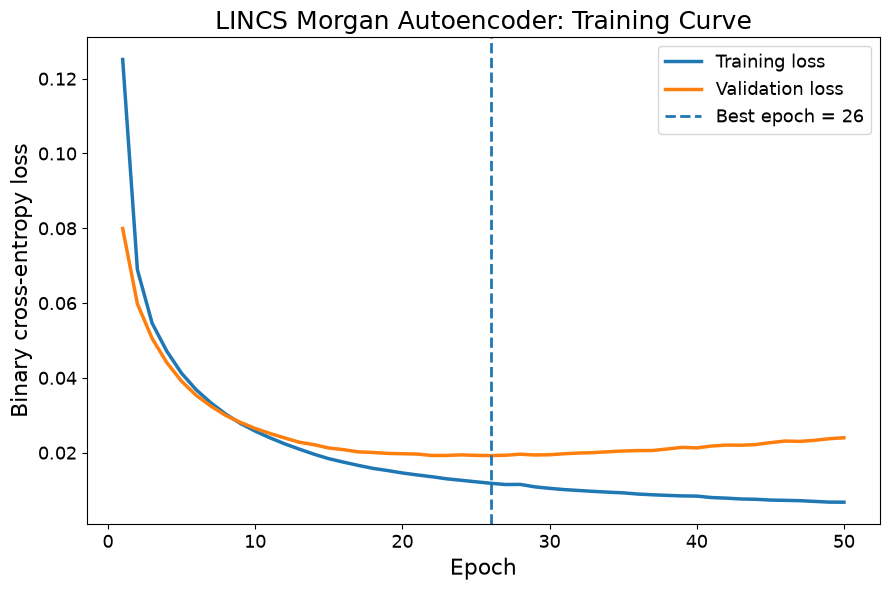

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    linewidth=2.5,
    label="Training loss"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    linewidth=2.5,
    label="Validation loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=2,
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Binary cross-entropy loss", fontsize=16)
plt.title("LINCS Morgan Autoencoder: Training Curve", fontsize=18)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)

plt.tight_layout()

plt.savefig(
    "../figures/lincs_morgan_autoencoder_training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

all_true_bits = []
all_pred_probs = []

best_model.eval()

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = best_model(batch)

        all_true_bits.append(batch.cpu().numpy())
        all_pred_probs.append(reconstructed.cpu().numpy())

all_true_bits = np.vstack(all_true_bits)
all_pred_probs = np.vstack(all_pred_probs)

# Threshold probabilities into predicted 0/1 fingerprint bits
all_pred_bits = (all_pred_probs >= 0.5).astype(int)

roc_auc_scores = []
f1_scores = []

for true_bits, pred_probs, pred_bits in zip(
    all_true_bits,
    all_pred_probs,
    all_pred_bits
):
    # ROC-AUC is undefined if a molecule has only one class,
    # though that should be rare for Morgan fingerprints.
    if len(np.unique(true_bits)) == 2:
        roc_auc_scores.append(
            roc_auc_score(true_bits, pred_probs)
        )

    f1_scores.append(
        f1_score(true_bits, pred_bits, zero_division=0)
    )

mean_roc_auc = np.mean(roc_auc_scores)
mean_f1 = np.mean(f1_scores)

print(f"Mean per-molecule ROC-AUC: {mean_roc_auc:.4f}")
print(f"Mean per-molecule F1 score: {mean_f1:.4f}")
print(f"Molecules included in ROC-AUC: {len(roc_auc_scores):,}")

Mean per-molecule ROC-AUC: 0.9784
Mean per-molecule F1 score: 0.8762
Molecules included in ROC-AUC: 4,287


In [18]:
LATENT_DIMS = [5, 10, 15, 30, 50]

In [19]:
import copy
import pandas as pd

LATENT_DIMS = [5, 10, 15, 30, 50]

NUM_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-3

bottleneck_results = []
bottleneck_models = {}

for latent_dim in LATENT_DIMS:
    print(f"\n{'=' * 60}")
    print(f"Training bottleneck size: {latent_dim}")
    print(f"{'=' * 60}")

    # Fresh autoencoder for this bottleneck size
    candidate_model = MorganAutoencoder(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim
    ).to(DEVICE)

    candidate_optimizer = optim.Adam(
        candidate_model.parameters(),
        lr=LEARNING_RATE
    )

    best_candidate_state = None
    best_candidate_val_loss = float("inf")
    best_candidate_epoch = 0
    epochs_without_improvement = 0

    candidate_train_losses = []
    candidate_val_losses = []

    for epoch in range(NUM_EPOCHS):
        # ---- Training ----
        candidate_model.train()
        running_train_loss = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)

            candidate_optimizer.zero_grad()

            reconstructed, _ = candidate_model(batch)
            loss = criterion(reconstructed, batch)

            loss.backward()
            candidate_optimizer.step()

            running_train_loss += loss.item() * batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        candidate_train_losses.append(epoch_train_loss)

        # ---- Validation ----
        candidate_model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)

                reconstructed, _ = candidate_model(batch)
                loss = criterion(reconstructed, batch)

                running_val_loss += loss.item() * batch.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        candidate_val_losses.append(epoch_val_loss)

        # ---- Early stopping / save best version ----
        if epoch_val_loss < best_candidate_val_loss:
            best_candidate_val_loss = epoch_val_loss
            best_candidate_epoch = epoch + 1
            epochs_without_improvement = 0

            best_candidate_state = copy.deepcopy(
                candidate_model.state_dict()
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best epoch: {best_candidate_epoch})"
            )
            break

    # Restore the best version of this candidate model
    candidate_model.load_state_dict(best_candidate_state)

    # Save model and results
    bottleneck_models[latent_dim] = candidate_model

    torch.save(
        candidate_model.state_dict(),
        f"../models/lincs_morgan_autoencoder_latent{latent_dim}_best.pt"
    )

    bottleneck_results.append({
        "latent_dim": latent_dim,
        "best_epoch": best_candidate_epoch,
        "best_val_bce": best_candidate_val_loss,
        "final_train_bce": candidate_train_losses[-1],
        "epochs_completed": len(candidate_train_losses)
    })

    print(
        f"Latent dim {latent_dim}: "
        f"best validation BCE = {best_candidate_val_loss:.5f} "
        f"at epoch {best_candidate_epoch}"
    )

bottleneck_results_df = pd.DataFrame(bottleneck_results)

display(
    bottleneck_results_df.sort_values("best_val_bce")
)


Training bottleneck size: 5
Latent dim 5: best validation BCE = 0.02659 at epoch 46

Training bottleneck size: 10
Early stopping at epoch 33 (best epoch: 25)
Latent dim 10: best validation BCE = 0.02113 at epoch 25

Training bottleneck size: 15
Early stopping at epoch 32 (best epoch: 24)
Latent dim 15: best validation BCE = 0.01900 at epoch 24

Training bottleneck size: 30
Early stopping at epoch 33 (best epoch: 25)
Latent dim 30: best validation BCE = 0.01870 at epoch 25

Training bottleneck size: 50
Early stopping at epoch 34 (best epoch: 26)
Latent dim 50: best validation BCE = 0.01821 at epoch 26


,latent_dim,best_epoch,best_val_bce,final_train_bce,epochs_completed
4,50,26,0.018212,0.008105,34
3,30,25,0.018696,0.008389,33
2,15,24,0.018996,0.009095,32
1,10,25,0.021130,0.011707,33
0,5,46,0.026593,0.017742,50


In [20]:
import copy
import pandas as pd
import torch
import torch.optim as optim

# Only the bottlenecks missing from yesterday's full range
MISSING_LATENT_DIMS = [2, 25, 100]

NUM_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-3

new_bottleneck_results = []

for latent_dim in MISSING_LATENT_DIMS:
    print(f"\n{'=' * 60}")
    print(f"Training bottleneck size: {latent_dim}")
    print(f"{'=' * 60}")

    # Fresh model for this bottleneck size
    candidate_model = MorganAutoencoder(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim
    ).to(DEVICE)

    candidate_optimizer = optim.Adam(
        candidate_model.parameters(),
        lr=LEARNING_RATE
    )

    best_candidate_state = None
    best_candidate_val_loss = float("inf")
    best_candidate_epoch = 0
    epochs_without_improvement = 0

    candidate_train_losses = []
    candidate_val_losses = []

    for epoch in range(NUM_EPOCHS):
        # ----- Training -----
        candidate_model.train()
        running_train_loss = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)

            candidate_optimizer.zero_grad()

            reconstructed, _ = candidate_model(batch)
            loss = criterion(reconstructed, batch)

            loss.backward()
            candidate_optimizer.step()

            running_train_loss += loss.item() * batch.size(0)

        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )
        candidate_train_losses.append(epoch_train_loss)

        # ----- Validation -----
        candidate_model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)

                reconstructed, _ = candidate_model(batch)
                loss = criterion(reconstructed, batch)

                running_val_loss += loss.item() * batch.size(0)

        epoch_val_loss = (
            running_val_loss / len(val_loader.dataset)
        )
        candidate_val_losses.append(epoch_val_loss)

        # ----- Save best checkpoint / early stopping -----
        if epoch_val_loss < best_candidate_val_loss:
            best_candidate_val_loss = epoch_val_loss
            best_candidate_epoch = epoch + 1
            epochs_without_improvement = 0

            best_candidate_state = copy.deepcopy(
                candidate_model.state_dict()
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best epoch: {best_candidate_epoch})"
            )
            break

    # Restore the best validation-loss version
    candidate_model.load_state_dict(best_candidate_state)

    # Save its weights
    model_path = (
        f"../models/"
        f"lincs_morgan_autoencoder_latent{latent_dim}_best.pt"
    )
    torch.save(candidate_model.state_dict(), model_path)

    # Store its results
    new_bottleneck_results.append({
        "latent_dim": latent_dim,
        "best_epoch": best_candidate_epoch,
        "best_val_bce": best_candidate_val_loss,
        "final_train_bce": candidate_train_losses[-1],
        "epochs_completed": len(candidate_train_losses)
    })

    print(
        f"Latent dim {latent_dim}: "
        f"best validation BCE = {best_candidate_val_loss:.6f} "
        f"at epoch {best_candidate_epoch}"
    )

# Turn the three new results into a table
new_bottleneck_results_df = pd.DataFrame(new_bottleneck_results)


bottleneck_results_df = pd.concat(
    [bottleneck_results_df, new_bottleneck_results_df],
    ignore_index=True
)

# Safety check: keep one row per bottleneck size
bottleneck_results_df = (
    bottleneck_results_df
    .drop_duplicates(subset="latent_dim", keep="last")
    .sort_values("latent_dim")
    .reset_index(drop=True)
)

display(bottleneck_results_df)


Training bottleneck size: 2
Latent dim 2: best validation BCE = 0.039009 at epoch 48

Training bottleneck size: 25
Early stopping at epoch 34 (best epoch: 26)
Latent dim 25: best validation BCE = 0.018370 at epoch 26

Training bottleneck size: 100
Early stopping at epoch 30 (best epoch: 22)
Latent dim 100: best validation BCE = 0.018182 at epoch 22


,latent_dim,best_epoch,best_val_bce,final_train_bce,epochs_completed
0,2,48,0.039009,0.036539,50
1,5,46,0.026593,0.017742,50
2,10,25,0.021130,0.011707,33
3,15,24,0.018996,0.009095,32
4,25,26,0.018370,0.008240,34
5,30,25,0.018696,0.008389,33
6,50,26,0.018212,0.008105,34
7,100,22,0.018182,0.009061,30


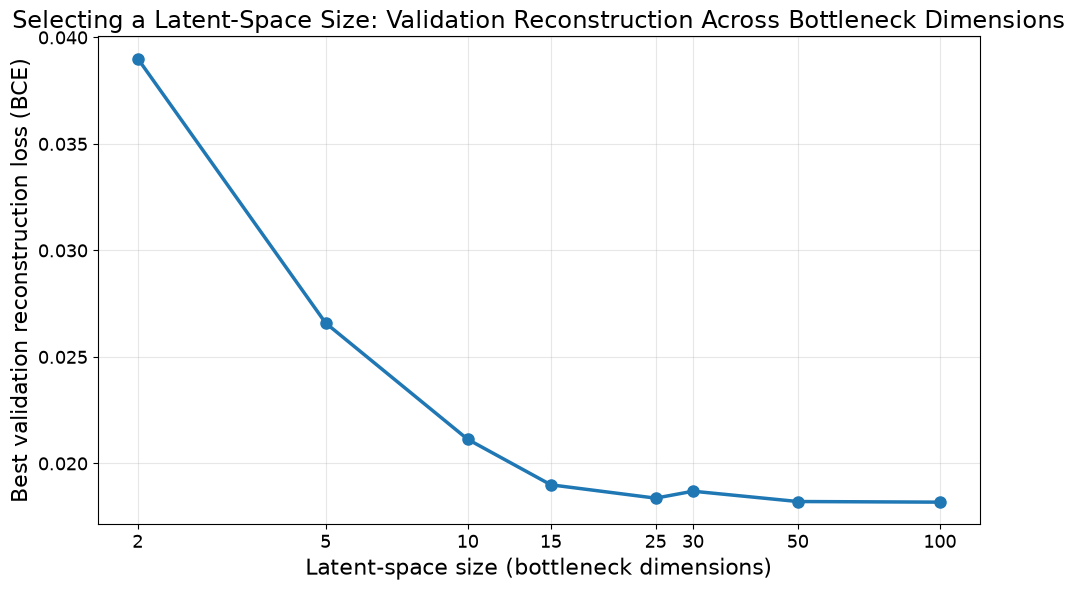

In [22]:
import matplotlib.pyplot as plt

plot_df = bottleneck_results_df.sort_values("latent_dim").copy()

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["latent_dim"],
    plot_df["best_val_bce"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

plt.xscale("log", base=2)

plt.xticks(
    plot_df["latent_dim"],
    labels=plot_df["latent_dim"],
    fontsize=13
)
plt.yticks(fontsize=13)

plt.xlabel(
    "Latent-space size (bottleneck dimensions)",
    fontsize=16
)
plt.ylabel(
    "Best validation reconstruction loss (BCE)",
    fontsize=16
)
plt.title(
    "Selecting a Latent-Space Size: Validation Reconstruction Across Bottleneck Dimensions",
    fontsize=17
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/lincs_bottleneck_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

# Systematic bottleneck sweep: powers of 2
POWER_OF_TWO_DIMS = [2, 4, 8, 16, 32, 64, 128]

NUM_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-3
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

power2_results = []

for latent_dim in POWER_OF_TWO_DIMS:
    print(f"\n{'=' * 60}")
    print(f"Training bottleneck size: {latent_dim}")
    print(f"{'=' * 60}")

    # Make initialization/comparison reproducible
    set_seed(SEED)

    candidate_model = MorganAutoencoder(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim
    ).to(DEVICE)

    candidate_optimizer = optim.Adam(
        candidate_model.parameters(),
        lr=LEARNING_RATE
    )

    best_candidate_state = None
    best_candidate_val_loss = float("inf")
    best_candidate_epoch = 0
    epochs_without_improvement = 0

    candidate_train_losses = []
    candidate_val_losses = []

    for epoch in range(NUM_EPOCHS):
        # ----- Training -----
        candidate_model.train()
        running_train_loss = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)

            candidate_optimizer.zero_grad()

            reconstructed, _ = candidate_model(batch)
            loss = criterion(reconstructed, batch)

            loss.backward()
            candidate_optimizer.step()

            running_train_loss += loss.item() * batch.size(0)

        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )
        candidate_train_losses.append(epoch_train_loss)

        # ----- Validation -----
        candidate_model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)

                reconstructed, _ = candidate_model(batch)
                loss = criterion(reconstructed, batch)

                running_val_loss += loss.item() * batch.size(0)

        epoch_val_loss = (
            running_val_loss / len(val_loader.dataset)
        )
        candidate_val_losses.append(epoch_val_loss)

        # ----- Save best version / early stopping -----
        if epoch_val_loss < best_candidate_val_loss:
            best_candidate_val_loss = epoch_val_loss
            best_candidate_epoch = epoch + 1
            epochs_without_improvement = 0

            best_candidate_state = copy.deepcopy(
                candidate_model.state_dict()
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best epoch: {best_candidate_epoch})"
            )
            break

    # Restore and save best checkpoint for this size
    candidate_model.load_state_dict(best_candidate_state)

    torch.save(
        candidate_model.state_dict(),
        f"../models/lincs_morgan_autoencoder_power2_latent{latent_dim}_best.pt"
    )

    power2_results.append({
        "latent_dim": latent_dim,
        "best_epoch": best_candidate_epoch,
        "best_val_bce": best_candidate_val_loss,
        "final_train_bce": candidate_train_losses[-1],
        "epochs_completed": len(candidate_train_losses)
    })

    print(
        f"Latent dim {latent_dim}: "
        f"best validation BCE = {best_candidate_val_loss:.6f} "
        f"at epoch {best_candidate_epoch}"
    )

power2_results_df = (
    pd.DataFrame(power2_results)
    .sort_values("latent_dim")
    .reset_index(drop=True)
)

display(power2_results_df)


Training bottleneck size: 2
Latent dim 2: best validation BCE = 0.039226 at epoch 50

Training bottleneck size: 4
Latent dim 4: best validation BCE = 0.029921 at epoch 48

Training bottleneck size: 8
Early stopping at epoch 38 (best epoch: 30)
Latent dim 8: best validation BCE = 0.022643 at epoch 30

Training bottleneck size: 16
Early stopping at epoch 32 (best epoch: 24)
Latent dim 16: best validation BCE = 0.019237 at epoch 24

Training bottleneck size: 32
Early stopping at epoch 34 (best epoch: 26)
Latent dim 32: best validation BCE = 0.018857 at epoch 26

Training bottleneck size: 64
Early stopping at epoch 33 (best epoch: 25)
Latent dim 64: best validation BCE = 0.018295 at epoch 25

Training bottleneck size: 128
Early stopping at epoch 31 (best epoch: 23)
Latent dim 128: best validation BCE = 0.018140 at epoch 23


,latent_dim,best_epoch,best_val_bce,final_train_bce,epochs_completed
0,2,50,0.039226,0.036484,50
1,4,48,0.029921,0.022887,50
2,8,30,0.022643,0.012952,38
3,16,24,0.019237,0.009528,32
4,32,26,0.018857,0.008944,34
5,64,25,0.018295,0.009053,33
6,128,23,0.018140,0.008723,31


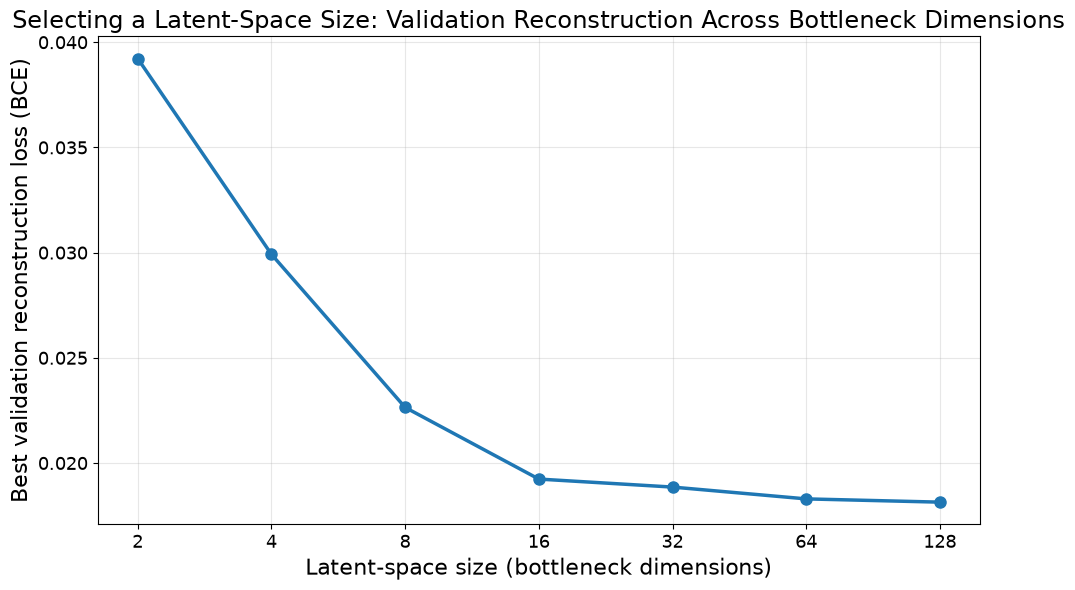

In [24]:
import matplotlib.pyplot as plt

plot_df = power2_results_df.sort_values("latent_dim").copy()

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["latent_dim"],
    plot_df["best_val_bce"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

# These are powers of 2, so use a base-2 log x-axis
plt.xscale("log", base=2)

plt.xticks(
    plot_df["latent_dim"],
    labels=plot_df["latent_dim"],
    fontsize=13
)
plt.yticks(fontsize=13)

plt.xlabel(
    "Latent-space size (bottleneck dimensions)",
    fontsize=16
)
plt.ylabel(
    "Best validation reconstruction loss (BCE)",
    fontsize=16
)
plt.title(
    "Selecting a Latent-Space Size: Validation Reconstruction Across Bottleneck Dimensions",
    fontsize=17
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/lincs_power2_bottleneck_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Training bottleneck size: 2
Latent   2 | Epoch  1/50 | Train BCE: 0.11506 | Val BCE: 0.07476
Latent   2 | Epoch  2/50 | Train BCE: 0.06779 | Val BCE: 0.06197
Latent   2 | Epoch  3/50 | Train BCE: 0.05960 | Val BCE: 0.05741
Latent   2 | Epoch  4/50 | Train BCE: 0.05584 | Val BCE: 0.05435
Latent   2 | Epoch  5/50 | Train BCE: 0.05336 | Val BCE: 0.05231
Latent   2 | Epoch  6/50 | Train BCE: 0.05133 | Val BCE: 0.05026
Latent   2 | Epoch  7/50 | Train BCE: 0.04983 | Val BCE: 0.04927
Latent   2 | Epoch  8/50 | Train BCE: 0.04873 | Val BCE: 0.04837
Latent   2 | Epoch  9/50 | Train BCE: 0.04780 | Val BCE: 0.04758
Latent   2 | Epoch 10/50 | Train BCE: 0.04705 | Val BCE: 0.04718
Latent   2 | Epoch 11/50 | Train BCE: 0.04644 | Val BCE: 0.04643
Latent   2 | Epoch 12/50 | Train BCE: 0.04587 | Val BCE: 0.04602
Latent   2 | Epoch 13/50 | Train BCE: 0.04525 | Val BCE: 0.04550
Latent   2 | Epoch 14/50 | Train BCE: 0.04476 | Val BCE: 0.04529
Latent   2 | Epoch 15/50 | Train BCE: 0.04433 | Val BCE: 0.04

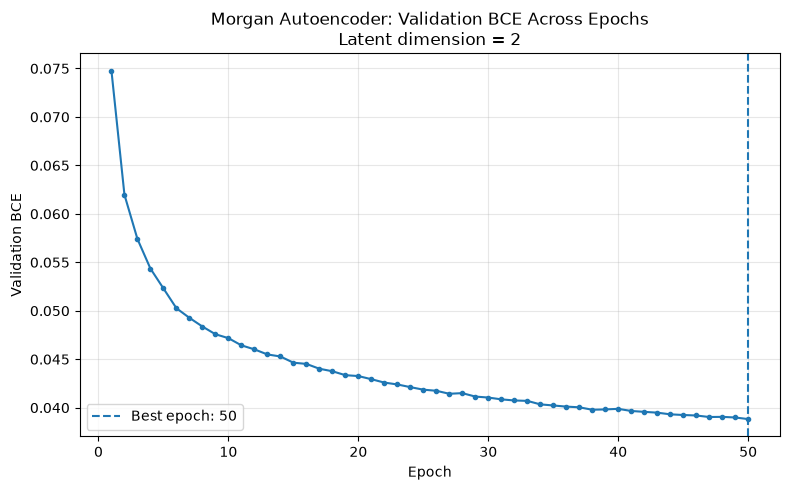


Training bottleneck size: 4
Latent   4 | Epoch  1/50 | Train BCE: 0.12599 | Val BCE: 0.07704
Latent   4 | Epoch  2/50 | Train BCE: 0.06691 | Val BCE: 0.05763
Latent   4 | Epoch  3/50 | Train BCE: 0.05320 | Val BCE: 0.04940
Latent   4 | Epoch  4/50 | Train BCE: 0.04755 | Val BCE: 0.04587
Latent   4 | Epoch  5/50 | Train BCE: 0.04449 | Val BCE: 0.04360
Latent   4 | Epoch  6/50 | Train BCE: 0.04243 | Val BCE: 0.04208
Latent   4 | Epoch  7/50 | Train BCE: 0.04083 | Val BCE: 0.04080
Latent   4 | Epoch  8/50 | Train BCE: 0.03948 | Val BCE: 0.03979
Latent   4 | Epoch  9/50 | Train BCE: 0.03840 | Val BCE: 0.03885
Latent   4 | Epoch 10/50 | Train BCE: 0.03735 | Val BCE: 0.03832
Latent   4 | Epoch 11/50 | Train BCE: 0.03645 | Val BCE: 0.03740
Latent   4 | Epoch 12/50 | Train BCE: 0.03562 | Val BCE: 0.03671
Latent   4 | Epoch 13/50 | Train BCE: 0.03483 | Val BCE: 0.03619
Latent   4 | Epoch 14/50 | Train BCE: 0.03418 | Val BCE: 0.03581
Latent   4 | Epoch 15/50 | Train BCE: 0.03351 | Val BCE: 0.03

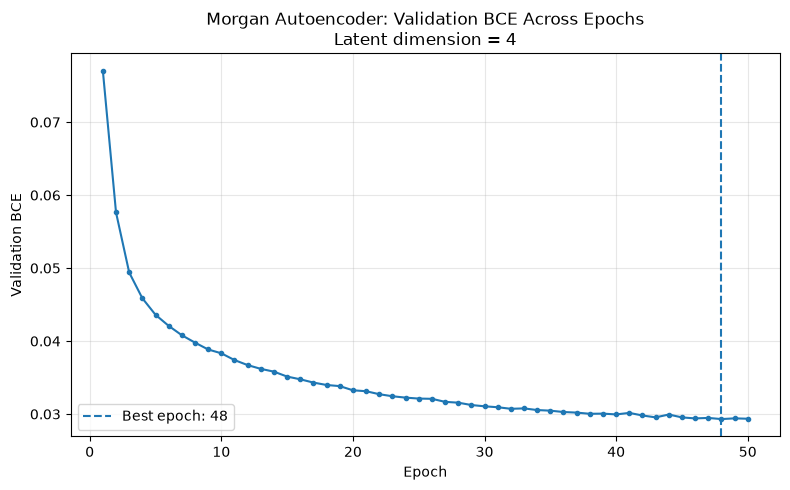


Training bottleneck size: 8
Latent   8 | Epoch  1/50 | Train BCE: 0.12394 | Val BCE: 0.08073
Latent   8 | Epoch  2/50 | Train BCE: 0.06854 | Val BCE: 0.05767
Latent   8 | Epoch  3/50 | Train BCE: 0.05317 | Val BCE: 0.04924
Latent   8 | Epoch  4/50 | Train BCE: 0.04677 | Val BCE: 0.04441
Latent   8 | Epoch  5/50 | Train BCE: 0.04212 | Val BCE: 0.04052
Latent   8 | Epoch  6/50 | Train BCE: 0.03858 | Val BCE: 0.03723
Latent   8 | Epoch  7/50 | Train BCE: 0.03507 | Val BCE: 0.03429
Latent   8 | Epoch  8/50 | Train BCE: 0.03244 | Val BCE: 0.03263
Latent   8 | Epoch  9/50 | Train BCE: 0.03040 | Val BCE: 0.03080
Latent   8 | Epoch 10/50 | Train BCE: 0.02871 | Val BCE: 0.02960
Latent   8 | Epoch 11/50 | Train BCE: 0.02723 | Val BCE: 0.02863
Latent   8 | Epoch 12/50 | Train BCE: 0.02595 | Val BCE: 0.02764
Latent   8 | Epoch 13/50 | Train BCE: 0.02475 | Val BCE: 0.02680
Latent   8 | Epoch 14/50 | Train BCE: 0.02368 | Val BCE: 0.02608
Latent   8 | Epoch 15/50 | Train BCE: 0.02270 | Val BCE: 0.02

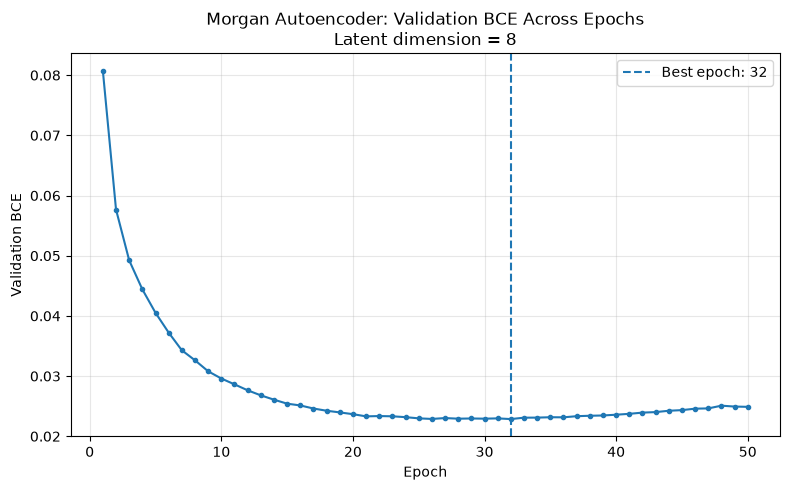


Training bottleneck size: 16
Latent  16 | Epoch  1/50 | Train BCE: 0.12651 | Val BCE: 0.07761
Latent  16 | Epoch  2/50 | Train BCE: 0.06745 | Val BCE: 0.05774
Latent  16 | Epoch  3/50 | Train BCE: 0.05217 | Val BCE: 0.04719
Latent  16 | Epoch  4/50 | Train BCE: 0.04408 | Val BCE: 0.04152
Latent  16 | Epoch  5/50 | Train BCE: 0.03927 | Val BCE: 0.03786
Latent  16 | Epoch  6/50 | Train BCE: 0.03545 | Val BCE: 0.03436
Latent  16 | Epoch  7/50 | Train BCE: 0.03195 | Val BCE: 0.03143
Latent  16 | Epoch  8/50 | Train BCE: 0.02903 | Val BCE: 0.02917
Latent  16 | Epoch  9/50 | Train BCE: 0.02672 | Val BCE: 0.02755
Latent  16 | Epoch 10/50 | Train BCE: 0.02480 | Val BCE: 0.02598
Latent  16 | Epoch 11/50 | Train BCE: 0.02291 | Val BCE: 0.02455
Latent  16 | Epoch 12/50 | Train BCE: 0.02125 | Val BCE: 0.02323
Latent  16 | Epoch 13/50 | Train BCE: 0.01978 | Val BCE: 0.02221
Latent  16 | Epoch 14/50 | Train BCE: 0.01854 | Val BCE: 0.02171
Latent  16 | Epoch 15/50 | Train BCE: 0.01746 | Val BCE: 0.0

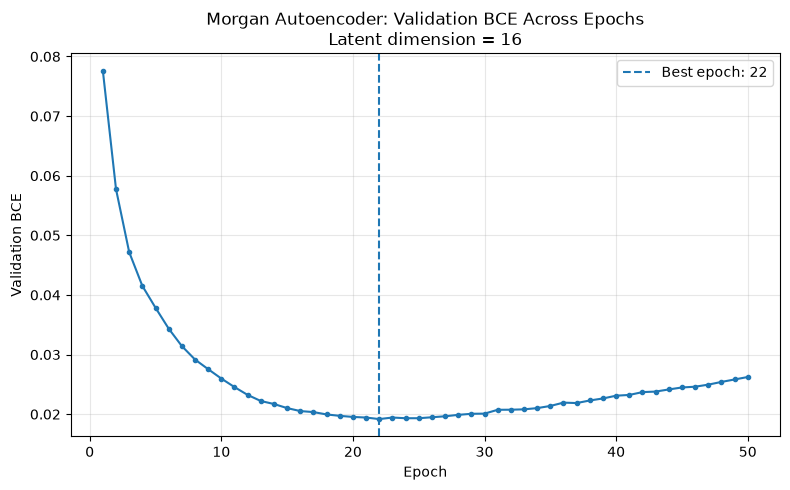


Training bottleneck size: 32
Latent  32 | Epoch  1/50 | Train BCE: 0.12724 | Val BCE: 0.08525
Latent  32 | Epoch  2/50 | Train BCE: 0.07365 | Val BCE: 0.06227
Latent  32 | Epoch  3/50 | Train BCE: 0.05582 | Val BCE: 0.05043
Latent  32 | Epoch  4/50 | Train BCE: 0.04680 | Val BCE: 0.04371
Latent  32 | Epoch  5/50 | Train BCE: 0.04144 | Val BCE: 0.03980
Latent  32 | Epoch  6/50 | Train BCE: 0.03753 | Val BCE: 0.03657
Latent  32 | Epoch  7/50 | Train BCE: 0.03418 | Val BCE: 0.03362
Latent  32 | Epoch  8/50 | Train BCE: 0.03115 | Val BCE: 0.03090
Latent  32 | Epoch  9/50 | Train BCE: 0.02820 | Val BCE: 0.02826
Latent  32 | Epoch 10/50 | Train BCE: 0.02568 | Val BCE: 0.02655
Latent  32 | Epoch 11/50 | Train BCE: 0.02366 | Val BCE: 0.02497
Latent  32 | Epoch 12/50 | Train BCE: 0.02195 | Val BCE: 0.02363
Latent  32 | Epoch 13/50 | Train BCE: 0.02035 | Val BCE: 0.02250
Latent  32 | Epoch 14/50 | Train BCE: 0.01893 | Val BCE: 0.02140
Latent  32 | Epoch 15/50 | Train BCE: 0.01769 | Val BCE: 0.0

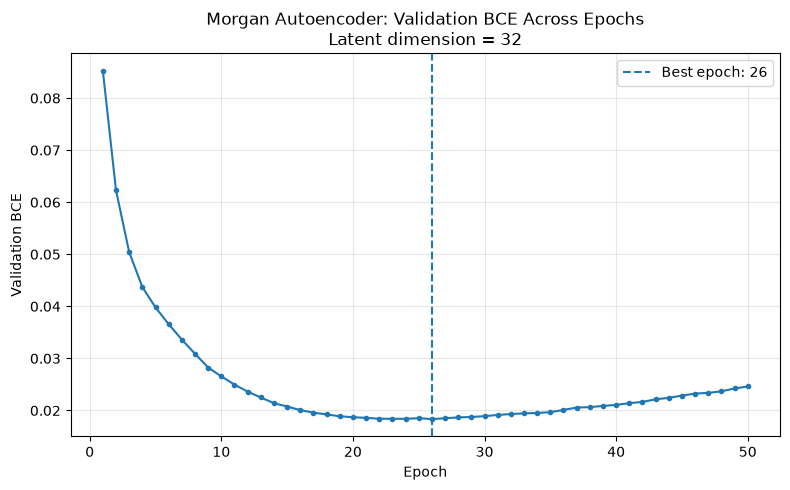


Training bottleneck size: 64
Latent  64 | Epoch  1/50 | Train BCE: 0.12746 | Val BCE: 0.08489
Latent  64 | Epoch  2/50 | Train BCE: 0.07335 | Val BCE: 0.06473
Latent  64 | Epoch  3/50 | Train BCE: 0.05720 | Val BCE: 0.05206
Latent  64 | Epoch  4/50 | Train BCE: 0.04892 | Val BCE: 0.04582
Latent  64 | Epoch  5/50 | Train BCE: 0.04336 | Val BCE: 0.04124
Latent  64 | Epoch  6/50 | Train BCE: 0.03842 | Val BCE: 0.03660
Latent  64 | Epoch  7/50 | Train BCE: 0.03410 | Val BCE: 0.03341
Latent  64 | Epoch  8/50 | Train BCE: 0.03063 | Val BCE: 0.03022
Latent  64 | Epoch  9/50 | Train BCE: 0.02759 | Val BCE: 0.02789
Latent  64 | Epoch 10/50 | Train BCE: 0.02488 | Val BCE: 0.02550
Latent  64 | Epoch 11/50 | Train BCE: 0.02253 | Val BCE: 0.02374
Latent  64 | Epoch 12/50 | Train BCE: 0.02063 | Val BCE: 0.02228
Latent  64 | Epoch 13/50 | Train BCE: 0.01897 | Val BCE: 0.02117
Latent  64 | Epoch 14/50 | Train BCE: 0.01764 | Val BCE: 0.02036
Latent  64 | Epoch 15/50 | Train BCE: 0.01652 | Val BCE: 0.0

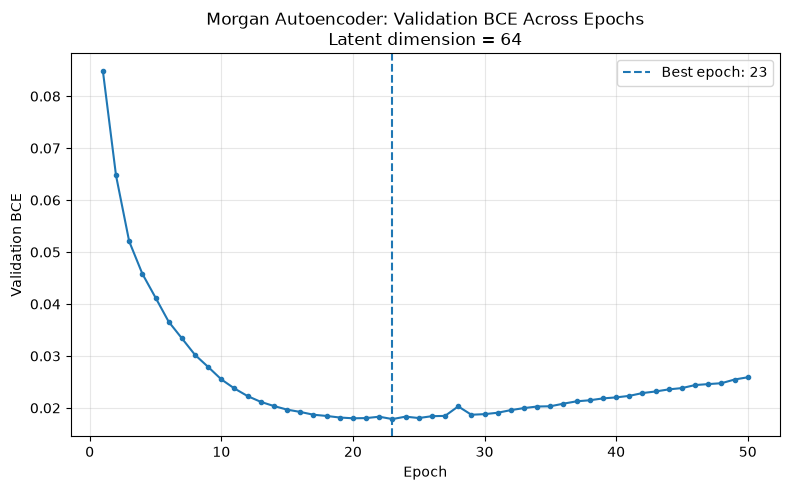


Training bottleneck size: 128
Latent 128 | Epoch  1/50 | Train BCE: 0.12461 | Val BCE: 0.08555
Latent 128 | Epoch  2/50 | Train BCE: 0.07463 | Val BCE: 0.06257
Latent 128 | Epoch  3/50 | Train BCE: 0.05668 | Val BCE: 0.05262
Latent 128 | Epoch  4/50 | Train BCE: 0.04950 | Val BCE: 0.04590
Latent 128 | Epoch  5/50 | Train BCE: 0.04367 | Val BCE: 0.04192
Latent 128 | Epoch  6/50 | Train BCE: 0.03945 | Val BCE: 0.03763
Latent 128 | Epoch  7/50 | Train BCE: 0.03543 | Val BCE: 0.03458
Latent 128 | Epoch  8/50 | Train BCE: 0.03243 | Val BCE: 0.03219
Latent 128 | Epoch  9/50 | Train BCE: 0.02990 | Val BCE: 0.03000
Latent 128 | Epoch 10/50 | Train BCE: 0.02772 | Val BCE: 0.02820
Latent 128 | Epoch 11/50 | Train BCE: 0.02569 | Val BCE: 0.02677
Latent 128 | Epoch 12/50 | Train BCE: 0.02377 | Val BCE: 0.02511
Latent 128 | Epoch 13/50 | Train BCE: 0.02209 | Val BCE: 0.02370
Latent 128 | Epoch 14/50 | Train BCE: 0.02057 | Val BCE: 0.02268
Latent 128 | Epoch 15/50 | Train BCE: 0.01920 | Val BCE: 0.

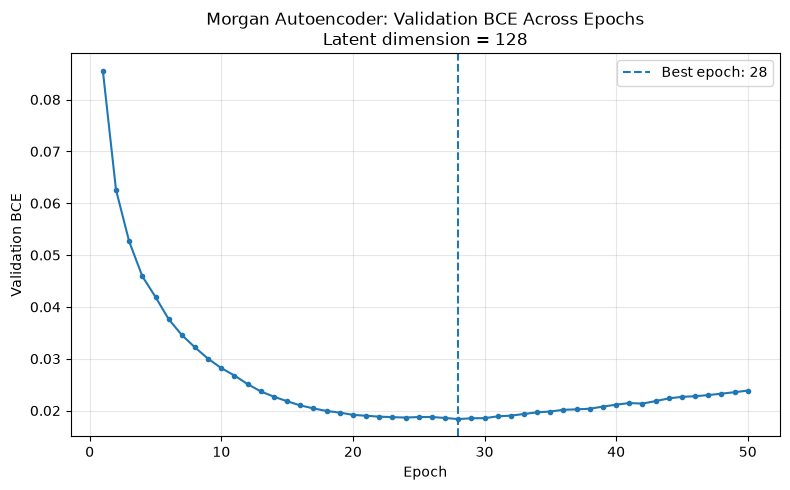

,latent_dim,best_epoch,best_val_bce,final_train_bce,final_val_bce
0,2,50,0.038826,0.036499,0.038826
1,4,48,0.029309,0.022326,0.029357
2,8,32,0.022859,0.011377,0.024894
3,16,22,0.019180,0.005847,0.026238
4,32,26,0.018350,0.005069,0.024611
5,64,23,0.017854,0.004350,0.025900
6,128,28,0.018365,0.005637,0.023860



Saved:
- Best model checkpoint for every latent dimension → ../models/
- One validation-BCE curve per latent dimension → ../figures/
- Epoch-level losses and summary tables → ../data/


In [11]:
import copy
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Full bottleneck sweep: no early stopping
LATENT_DIMS = [2, 4, 8, 16, 32, 64, 128]
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3

criterion = nn.BCELoss()

Path("../models").mkdir(exist_ok=True)
Path("../figures").mkdir(exist_ok=True)

full_sweep_results = []
epoch_loss_records = []
full_sweep_models = {}

for latent_dim in LATENT_DIMS:
    print(f"\n{'=' * 60}")
    print(f"Training bottleneck size: {latent_dim}")
    print(f"{'=' * 60}")

    # Fresh model and optimizer for each bottleneck size
    model = MorganAutoencoder(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_losses = []
    val_losses = []

    best_val_bce = float("inf")
    best_epoch = None
    best_state = None

    for epoch in range(NUM_EPOCHS):
        # Training
        model.train()
        train_loss_total = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)

            optimizer.zero_grad()
            reconstructed, _ = model(batch)
            loss = criterion(reconstructed, batch)

            loss.backward()
            optimizer.step()

            train_loss_total += loss.item() * batch.size(0)

        epoch_train_bce = train_loss_total / len(train_loader.dataset)
        train_losses.append(epoch_train_bce)

        # Validation
        model.eval()
        val_loss_total = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)

                reconstructed, _ = model(batch)
                loss = criterion(reconstructed, batch)

                val_loss_total += loss.item() * batch.size(0)

        epoch_val_bce = val_loss_total / len(val_loader.dataset)
        val_losses.append(epoch_val_bce)

        # Keep the best checkpoint, but continue through all 50 epochs
        if epoch_val_bce < best_val_bce:
            best_val_bce = epoch_val_bce
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        epoch_loss_records.append({
            "latent_dim": latent_dim,
            "epoch": epoch + 1,
            "train_bce": epoch_train_bce,
            "val_bce": epoch_val_bce
        })

        print(
            f"Latent {latent_dim:>3} | "
            f"Epoch {epoch + 1:>2}/{NUM_EPOCHS} | "
            f"Train BCE: {epoch_train_bce:.5f} | "
            f"Val BCE: {epoch_val_bce:.5f}"
        )

    # Restore and save each bottleneck's best-validation model
    model.load_state_dict(best_state)
    full_sweep_models[latent_dim] = copy.deepcopy(model)

    torch.save(
        model.state_dict(),
        f"../models/morgan_autoencoder_latent_{latent_dim}_best.pt"
    )

    full_sweep_results.append({
        "latent_dim": latent_dim,
        "best_epoch": best_epoch,
        "best_val_bce": best_val_bce,
        "final_train_bce": train_losses[-1],
        "final_val_bce": val_losses[-1]
    })

    # Separate validation-loss curve for this bottleneck
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), val_losses, marker="o", markersize=3)
    plt.axvline(best_epoch, linestyle="--", label=f"Best epoch: {best_epoch}")
    plt.xlabel("Epoch")
    plt.ylabel("Validation BCE")
    plt.title(f"Morgan Autoencoder: Validation BCE Across Epochs\nLatent dimension = {latent_dim}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        f"../figures/morgan_val_bce_latent_{latent_dim}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# Save summary tables
full_sweep_results_df = (
    pd.DataFrame(full_sweep_results)
    .sort_values("latent_dim")
    .reset_index(drop=True)
)

epoch_losses_df = pd.DataFrame(epoch_loss_records)

full_sweep_results_df.to_csv(
    "../data/morgan_full_50_epoch_bottleneck_summary.csv",
    index=False
)

epoch_losses_df.to_csv(
    "../data/morgan_full_50_epoch_loss_curves.csv",
    index=False
)

display(full_sweep_results_df)
print("\nSaved:")
print("- Best model checkpoint for every latent dimension → ../models/")
print("- One validation-BCE curve per latent dimension → ../figures/")
print("- Epoch-level losses and summary tables → ../data/")

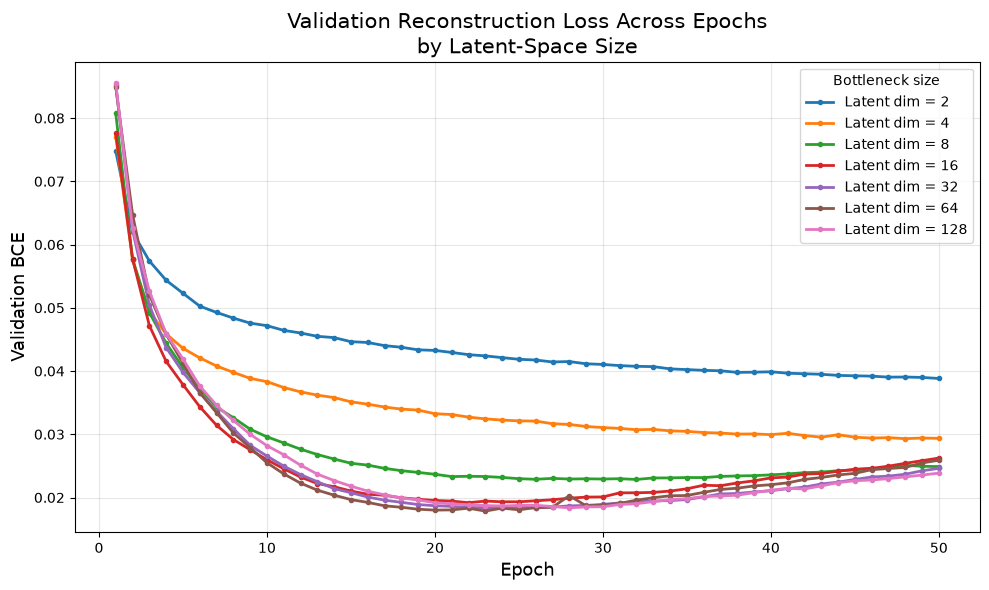

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for latent_dim in sorted(epoch_losses_df["latent_dim"].unique()):
    subset = epoch_losses_df[epoch_losses_df["latent_dim"] == latent_dim]

    plt.plot(
        subset["epoch"],
        subset["val_bce"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=f"Latent dim = {latent_dim}"
    )

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Validation BCE", fontsize=13)
plt.title(
    "Validation Reconstruction Loss Across Epochs\nby Latent-Space Size",
    fontsize=15
)
plt.legend(title="Bottleneck size")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/morgan_all_bottlenecks_val_bce_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Evaluate the selected 64-dimensional model on the untouched test set

SELECTED_LATENT_DIM = 64

# Re-create the 64D model and load its best validation checkpoint
selected_model = MorganAutoencoder(
    input_dim=INPUT_DIM,
    latent_dim=SELECTED_LATENT_DIM
).to(DEVICE)

selected_model.load_state_dict(
    torch.load(
        f"../models/morgan_autoencoder_latent_{SELECTED_LATENT_DIM}_best.pt",
        map_location=DEVICE
    )
)

selected_model.eval()

test_loss_total = 0.0
correct_bits = 0
total_bits = 0

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = selected_model(batch)

        # BCE on the untouched test set
        loss = criterion(reconstructed, batch)
        test_loss_total += loss.item() * batch.size(0)

        # Convert predicted probabilities into 0/1 fingerprint bits
        predicted_bits = (reconstructed >= 0.5).float()

        correct_bits += (predicted_bits == batch).sum().item()
        total_bits += batch.numel()

test_bce = test_loss_total / len(test_loader.dataset)
test_bitwise_accuracy = correct_bits / total_bits

print(f"Selected latent dimension: {SELECTED_LATENT_DIM}")
print(f"Test BCE: {test_bce:.6f}")
print(f"Test bitwise reconstruction accuracy: {test_bitwise_accuracy:.4%}")

Selected latent dimension: 64
Test BCE: 0.017219
Test bitwise reconstruction accuracy: 99.5754%


In [14]:
from sklearn.metrics import average_precision_score
import numpy as np

per_molecule_pr_auc = []
per_molecule_tanimoto = []

selected_model.eval()

with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(DEVICE)

        reconstructed, _ = selected_model(batch)

        true_bits = batch.cpu().numpy()
        predicted_probs = reconstructed.cpu().numpy()

        # PR-AUC / Average Precision: uses probabilities, no 0.5 cutoff
        for y_true, y_score in zip(true_bits, predicted_probs):
            if y_true.sum() > 0:  # requires at least one positive bit
                per_molecule_pr_auc.append(
                    average_precision_score(y_true, y_score)
                )

        # Tanimoto: compare thresholded reconstructed fingerprint to true fingerprint
        predicted_bits = (reconstructed >= 0.5).float()

        intersection = (predicted_bits * batch).sum(dim=1)
        union = ((predicted_bits + batch) > 0).float().sum(dim=1)

        tanimoto = intersection / torch.clamp(union, min=1)
        per_molecule_tanimoto.extend(tanimoto.cpu().numpy())

per_molecule_pr_auc = np.array(per_molecule_pr_auc)
per_molecule_tanimoto = np.array(per_molecule_tanimoto)

print(f"Compounds evaluated for PR-AUC: {len(per_molecule_pr_auc):,}")
print(f"Mean per-molecule PR-AUC:       {per_molecule_pr_auc.mean():.4f}")
print(f"Median per-molecule PR-AUC:     {np.median(per_molecule_pr_auc):.4f}")
print()
print(f"Compounds evaluated for Tanimoto: {len(per_molecule_tanimoto):,}")
print(f"Mean per-molecule Tanimoto:       {per_molecule_tanimoto.mean():.4f}")
print(f"Median per-molecule Tanimoto:     {np.median(per_molecule_tanimoto):.4f}")

Compounds evaluated for PR-AUC: 4,287
Mean per-molecule PR-AUC:       0.9057
Median per-molecule PR-AUC:     1.0000

Compounds evaluated for Tanimoto: 4,287
Mean per-molecule Tanimoto:       0.8386
Median per-molecule Tanimoto:     0.9828


In [15]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path

# Confirm the full fingerprint matrix and metadata are aligned
assert len(morgan_fingerprints) == len(cleaned_metadata), (
    "Fingerprint matrix and metadata have different numbers of rows."
)

# Recreate the exact split assignments from earlier
all_indices = np.arange(len(morgan_fingerprints))

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

split_labels = np.full(len(morgan_fingerprints), "unassigned", dtype=object)
split_labels[train_idx] = "train"
split_labels[val_idx] = "validation"
split_labels[test_idx] = "test"

# Make a loader for every compound, preserving original row order
all_dataset = TensorDataset(
    torch.tensor(morgan_fingerprints, dtype=torch.float32)
)

all_loader = DataLoader(
    all_dataset,
    batch_size=128,
    shuffle=False
)

# Extract 64D latent vectors using the saved best-validation model
selected_model.eval()
all_latent_vectors = []

with torch.no_grad():
    for (batch,) in all_loader:
        batch = batch.to(DEVICE)

        _, latent = selected_model(batch)
        all_latent_vectors.append(latent.cpu().numpy())

all_latent_vectors = np.vstack(all_latent_vectors)

# Turn vectors into a labeled DataFrame
latent_columns = [
    f"latent_{i + 1}"
    for i in range(all_latent_vectors.shape[1])
]

latent_df = pd.DataFrame(
    all_latent_vectors,
    columns=latent_columns
)

# Combine original compound metadata, split labels, and latent vectors
vectors_with_metadata = cleaned_metadata.reset_index(drop=True).copy()
vectors_with_metadata["split"] = split_labels

vectors_with_metadata = pd.concat(
    [vectors_with_metadata, latent_df],
    axis=1
)

# Save
Path("../data").mkdir(exist_ok=True)

output_path = "../data/morgan_autoencoder_latent64_vectors.csv"

vectors_with_metadata.to_csv(
    output_path,
    index=False
)

print(f"Saved latent vectors to: {output_path}")
print(f"Output shape: {vectors_with_metadata.shape}")
print("\nSplit counts:")
print(vectors_with_metadata['split'].value_counts())

display(vectors_with_metadata.head())

In [16]:
print("Metadata rows:", len(lincs_valid))
print("Fingerprint rows:", len(morgan_fingerprints))
print("Same length:", len(lincs_valid) == len(morgan_fingerprints))

display(lincs_valid.head())

Metadata rows: 28574
Fingerprint rows: 28574
Same length: True


,Unnamed: 0,pert_name,target,moa,canonical_smiles,inchi_key,compound_aliases,sig_count,valid_smiles
0,BRD-K60230970,MG-132,PSMB1,Proteasome inhibitor,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(...,TZYWCYJVHRLUCT-VABKMULXSA-N,-,8257,True
1,BRD-K50691590,bortezomib,"PSMB2, PSMB5, PSMB1","Proteasome inhibitor, NFKB pathway inhibitor",CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...,RFGAQTOFZHCFHG-NVXWUHKLSA-N,-,6776,True
2,BRD-K81418486,vorinostat,"HDAC8, HDAC2, HDAC3, HDAC6, HDAC1",HDAC inhibitor,ONC(=O)CCCCCCC(=O)Nc1ccccc1,WAEXFXRVDQXREF-UHFFFAOYSA-N,-,3244,True
3,BRD-K49865102,PD-0325901,MAP2K1,"MEK inhibitor, Protein kinase inhibitor, MAP k...",OC[C@@H](O)CONC(=O)c1ccc(F)c(F)c1Nc1ccc(I)cc1F,SUDAHWBOROXANE-SECBINFHSA-N,-,1796,True
4,BRD-K21680192,mitoxantrone,TOP2A,Topoisomerase inhibitor,OCCNCCNc1ccc(NCCNCCO)c2C(=O)c3c(O)ccc(O)c3C(=O...,KKZJGLLVHKMTCM-UHFFFAOYSA-N,-,1740,True


In [17]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path

# Confirm the fingerprint rows and metadata rows match
assert len(morgan_fingerprints) == len(lincs_valid), (
    "Fingerprint matrix and lincs_valid have different numbers of rows."
)

# Recreate the exact 70/15/15 split assignments
all_indices = np.arange(len(morgan_fingerprints))

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

split_labels = np.full(len(morgan_fingerprints), "unassigned", dtype=object)
split_labels[train_idx] = "train"
split_labels[val_idx] = "validation"
split_labels[test_idx] = "test"

# Loader for all compounds, preserving original row order
all_dataset = TensorDataset(
    torch.tensor(morgan_fingerprints, dtype=torch.float32)
)

all_loader = DataLoader(
    all_dataset,
    batch_size=128,
    shuffle=False
)

# Extract latent vectors from the selected best 64D model
selected_model.eval()
all_latent_vectors = []

with torch.no_grad():
    for (batch,) in all_loader:
        batch = batch.to(DEVICE)

        _, latent = selected_model(batch)
        all_latent_vectors.append(latent.cpu().numpy())

all_latent_vectors = np.vstack(all_latent_vectors)

# Name latent-vector columns
latent_columns = [
    f"latent_{i + 1}"
    for i in range(all_latent_vectors.shape[1])
]

latent_df = pd.DataFrame(
    all_latent_vectors,
    columns=latent_columns
)

# Combine compound metadata, split labels, and latent vectors
vectors_with_metadata = lincs_valid.reset_index(drop=True).copy()
vectors_with_metadata["split"] = split_labels

vectors_with_metadata = pd.concat(
    [vectors_with_metadata, latent_df],
    axis=1
)

# Save final vector file
Path("../data").mkdir(exist_ok=True)

output_path = "../data/morgan_autoencoder_latent64_vectors.csv"

vectors_with_metadata.to_csv(
    output_path,
    index=False
)

print(f"Saved latent vectors to: {output_path}")
print(f"Output shape: {vectors_with_metadata.shape}")
print("\nSplit counts:")
print(vectors_with_metadata["split"].value_counts())

display(vectors_with_metadata.head())

Saved latent vectors to: ../data/morgan_autoencoder_latent64_vectors.csv
Output shape: (28574, 74)

Split counts:
split
train         20001
test           4287
validation     4286
Name: count, dtype: int64


,Unnamed: 0,pert_name,target,moa,canonical_smiles,inchi_key,compound_aliases,sig_count,valid_smiles,split,...,latent_55,latent_56,latent_57,latent_58,latent_59,latent_60,latent_61,latent_62,latent_63,latent_64
0,BRD-K60230970,MG-132,PSMB1,Proteasome inhibitor,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(...,TZYWCYJVHRLUCT-VABKMULXSA-N,-,8257,True,train,...,-19.820385,-7.112452,4.440944,-9.822842,-9.839583,-9.229491,1.932333,-5.603589,-3.211800,-7.677505
1,BRD-K50691590,bortezomib,"PSMB2, PSMB5, PSMB1","Proteasome inhibitor, NFKB pathway inhibitor",CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...,RFGAQTOFZHCFHG-NVXWUHKLSA-N,-,6776,True,train,...,-13.786310,-4.547864,3.391103,-5.140367,-4.442291,-8.648558,2.156909,-9.736707,0.458286,-4.402381
2,BRD-K81418486,vorinostat,"HDAC8, HDAC2, HDAC3, HDAC6, HDAC1",HDAC inhibitor,ONC(=O)CCCCCCC(=O)Nc1ccccc1,WAEXFXRVDQXREF-UHFFFAOYSA-N,-,3244,True,train,...,-16.452637,-9.933352,11.547052,-3.825564,-8.993432,-8.666147,-5.651190,-5.757975,2.577652,-6.742383
3,BRD-K49865102,PD-0325901,MAP2K1,"MEK inhibitor, Protein kinase inhibitor, MAP k...",OC[C@@H](O)CONC(=O)c1ccc(F)c(F)c1Nc1ccc(I)cc1F,SUDAHWBOROXANE-SECBINFHSA-N,-,1796,True,test,...,-20.394136,-7.541327,7.494266,-9.395048,-2.053769,-10.210070,0.245343,-6.107342,-1.402413,-7.992792
4,BRD-K21680192,mitoxantrone,TOP2A,Topoisomerase inhibitor,OCCNCCNc1ccc(NCCNCCO)c2C(=O)c3c(O)ccc(O)c3C(=O...,KKZJGLLVHKMTCM-UHFFFAOYSA-N,-,1740,True,train,...,-20.724556,-4.973541,5.448934,-4.093791,-3.385640,-4.707429,-1.505551,-4.358154,3.886660,-6.215302


In [1]:
# Cross-Representation Autoencoder: Morgan → MACCS

In [8]:
# Check which previously created fingerprint matrices are currently loaded

for name in [
    "morgan_fingerprints",
    "maccs_fingerprints",
    "lincs_valid",
    "X_train",
    "X_val",
    "X_test"
]:
    print(f"{name}: {'✓ loaded' if name in globals() else 'MISSING'}")

morgan_fingerprints: ✓ loaded
maccs_fingerprints: MISSING
lincs_valid: ✓ loaded
X_train: MISSING
X_val: MISSING
X_test: MISSING


In [9]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys
import numpy as np

maccs_rows = []
invalid_smiles = []

for idx, smiles in enumerate(lincs_valid["canonical_smiles"]):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        invalid_smiles.append(idx)
        maccs_rows.append(np.zeros(167, dtype=np.float32))
    else:
        maccs_fp = MACCSkeys.GenMACCSKeys(mol)
        maccs_rows.append(
            np.array(list(maccs_fp), dtype=np.float32)
        )

maccs_fingerprints = np.vstack(maccs_rows)

print("Morgan shape:", morgan_fingerprints.shape)
print("MACCS shape:", maccs_fingerprints.shape)
print("Invalid SMILES:", len(invalid_smiles))

assert len(morgan_fingerprints) == len(maccs_fingerprints) == len(lincs_valid)
assert maccs_fingerprints.shape[1] == 167

Morgan shape: (28574, 2048)
MACCS shape: (28574, 167)
Invalid SMILES: 0


In [10]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# Recreate the same 70/15/15 compound split
all_indices = np.arange(len(morgan_fingerprints))

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

# Morgan inputs; MACCS reconstruction targets
X_morgan_train = morgan_fingerprints[train_idx]
X_morgan_val = morgan_fingerprints[val_idx]
X_morgan_test = morgan_fingerprints[test_idx]

Y_maccs_train = maccs_fingerprints[train_idx]
Y_maccs_val = maccs_fingerprints[val_idx]
Y_maccs_test = maccs_fingerprints[test_idx]

BATCH_SIZE = 128

train_dataset_morgan_to_maccs = TensorDataset(
    torch.tensor(X_morgan_train, dtype=torch.float32),
    torch.tensor(Y_maccs_train, dtype=torch.float32)
)

val_dataset_morgan_to_maccs = TensorDataset(
    torch.tensor(X_morgan_val, dtype=torch.float32),
    torch.tensor(Y_maccs_val, dtype=torch.float32)
)

test_dataset_morgan_to_maccs = TensorDataset(
    torch.tensor(X_morgan_test, dtype=torch.float32),
    torch.tensor(Y_maccs_test, dtype=torch.float32)
)

train_loader_morgan_to_maccs = DataLoader(
    train_dataset_morgan_to_maccs,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_morgan_to_maccs = DataLoader(
    val_dataset_morgan_to_maccs,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_morgan_to_maccs = DataLoader(
    test_dataset_morgan_to_maccs,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Morgan input shape:", X_morgan_train.shape)
print("Train MACCS target shape:", Y_maccs_train.shape)
print("Validation compounds:", len(val_dataset_morgan_to_maccs))
print("Test compounds:", len(test_dataset_morgan_to_maccs))

Train Morgan input shape: (20001, 2048)
Train MACCS target shape: (20001, 167)
Validation compounds: 4286
Test compounds: 4287


In [11]:
import torch.nn as nn

MORGAN_INPUT_DIM = 2048
MACCS_OUTPUT_DIM = 167
CROSS_LATENT_DIM = 32

class MorganToMACCSAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim=MORGAN_INPUT_DIM,
        latent_dim=CROSS_LATENT_DIM,
        output_dim=MACCS_OUTPUT_DIM
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed_maccs = self.decoder(latent)
        return reconstructed_maccs, latent


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

morgan_to_maccs_model = MorganToMACCSAutoencoder().to(DEVICE)

print("Using device:", DEVICE)
print(morgan_to_maccs_model)

Using device: cpu
MorganToMACCSAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=167, bias=True)
    (5): Sigmoid()
  )
)


In [12]:
import copy
import torch.optim as optim
from pathlib import Path

LEARNING_RATE = 1e-3
NUM_EPOCHS = 50

criterion_morgan_to_maccs = nn.BCELoss()
optimizer_morgan_to_maccs = optim.Adam(
    morgan_to_maccs_model.parameters(),
    lr=LEARNING_RATE
)

Path("../models").mkdir(exist_ok=True)

train_losses_morgan_to_maccs = []
val_losses_morgan_to_maccs = []

best_val_bce_morgan_to_maccs = float("inf")
best_epoch_morgan_to_maccs = None
best_state_morgan_to_maccs = None

for epoch in range(NUM_EPOCHS):
    # Training
    morgan_to_maccs_model.train()
    train_loss_total = 0.0

    for morgan_batch, maccs_batch in train_loader_morgan_to_maccs:
        morgan_batch = morgan_batch.to(DEVICE)
        maccs_batch = maccs_batch.to(DEVICE)

        optimizer_morgan_to_maccs.zero_grad()

        predicted_maccs, _ = morgan_to_maccs_model(morgan_batch)
        loss = criterion_morgan_to_maccs(predicted_maccs, maccs_batch)

        loss.backward()
        optimizer_morgan_to_maccs.step()

        train_loss_total += loss.item() * morgan_batch.size(0)

    epoch_train_bce = train_loss_total / len(train_loader_morgan_to_maccs.dataset)
    train_losses_morgan_to_maccs.append(epoch_train_bce)

    # Validation
    morgan_to_maccs_model.eval()
    val_loss_total = 0.0

    with torch.no_grad():
        for morgan_batch, maccs_batch in val_loader_morgan_to_maccs:
            morgan_batch = morgan_batch.to(DEVICE)
            maccs_batch = maccs_batch.to(DEVICE)

            predicted_maccs, _ = morgan_to_maccs_model(morgan_batch)
            loss = criterion_morgan_to_maccs(predicted_maccs, maccs_batch)

            val_loss_total += loss.item() * morgan_batch.size(0)

    epoch_val_bce = val_loss_total / len(val_loader_morgan_to_maccs.dataset)
    val_losses_morgan_to_maccs.append(epoch_val_bce)

    # Save best validation checkpoint, but keep training through epoch 50
    if epoch_val_bce < best_val_bce_morgan_to_maccs:
        best_val_bce_morgan_to_maccs = epoch_val_bce
        best_epoch_morgan_to_maccs = epoch + 1
        best_state_morgan_to_maccs = copy.deepcopy(
            morgan_to_maccs_model.state_dict()
        )

    print(
        f"Epoch {epoch + 1:>2}/{NUM_EPOCHS} | "
        f"Train BCE: {epoch_train_bce:.5f} | "
        f"Val BCE: {epoch_val_bce:.5f}"
    )

# Restore and save the best-validation version
morgan_to_maccs_model.load_state_dict(best_state_morgan_to_maccs)

checkpoint_path = "../models/morgan_to_maccs_latent32_best.pt"

torch.save(
    morgan_to_maccs_model.state_dict(),
    checkpoint_path
)

print("\nTraining complete.")
print(f"Best validation BCE: {best_val_bce_morgan_to_maccs:.6f}")
print(f"Best epoch: {best_epoch_morgan_to_maccs}")
print(f"Saved checkpoint: {checkpoint_path}")

Epoch  1/50 | Train BCE: 0.32625 | Val BCE: 0.22629
Epoch  2/50 | Train BCE: 0.18056 | Val BCE: 0.15762
Epoch  3/50 | Train BCE: 0.12914 | Val BCE: 0.11328
Epoch  4/50 | Train BCE: 0.09763 | Val BCE: 0.09008
Epoch  5/50 | Train BCE: 0.07773 | Val BCE: 0.07902
Epoch  6/50 | Train BCE: 0.06545 | Val BCE: 0.06904
Epoch  7/50 | Train BCE: 0.05621 | Val BCE: 0.06610
Epoch  8/50 | Train BCE: 0.04992 | Val BCE: 0.06067
Epoch  9/50 | Train BCE: 0.04478 | Val BCE: 0.05823
Epoch 10/50 | Train BCE: 0.04065 | Val BCE: 0.05626
Epoch 11/50 | Train BCE: 0.03713 | Val BCE: 0.05559
Epoch 12/50 | Train BCE: 0.03445 | Val BCE: 0.05466
Epoch 13/50 | Train BCE: 0.03221 | Val BCE: 0.05381
Epoch 14/50 | Train BCE: 0.02998 | Val BCE: 0.05424
Epoch 15/50 | Train BCE: 0.02834 | Val BCE: 0.05351
Epoch 16/50 | Train BCE: 0.02683 | Val BCE: 0.05309
Epoch 17/50 | Train BCE: 0.02496 | Val BCE: 0.05323
Epoch 18/50 | Train BCE: 0.02430 | Val BCE: 0.05470
Epoch 19/50 | Train BCE: 0.02255 | Val BCE: 0.05472
Epoch 20/50 

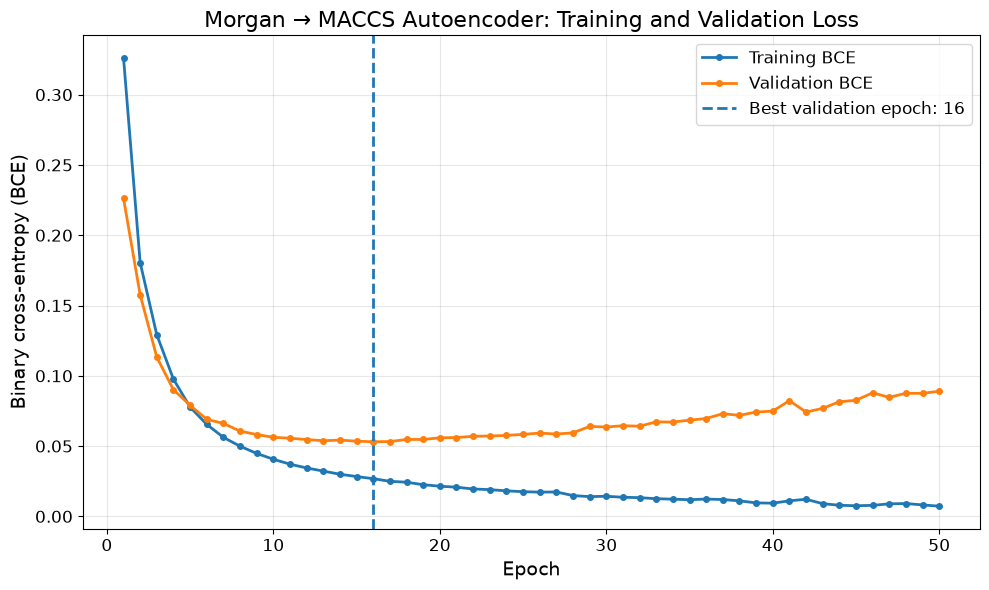

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses_morgan_to_maccs,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Training BCE"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses_morgan_to_maccs,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Validation BCE"
)

plt.axvline(
    best_epoch_morgan_to_maccs,
    linestyle="--",
    linewidth=2,
    label=f"Best validation epoch: {best_epoch_morgan_to_maccs}"
)

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Binary cross-entropy (BCE)", fontsize=14)

plt.title(
    "Morgan → MACCS Autoencoder: Training and Validation Loss",
    fontsize=16
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/morgan_to_maccs_latent32_bce_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# Evaluate the selected Morgan → MACCS model on the untouched test set

morgan_to_maccs_model.eval()

test_loss_total = 0.0
correct_bits = 0
total_bits = 0

with torch.no_grad():
    for morgan_batch, maccs_batch in test_loader_morgan_to_maccs:
        morgan_batch = morgan_batch.to(DEVICE)
        maccs_batch = maccs_batch.to(DEVICE)

        predicted_maccs, _ = morgan_to_maccs_model(morgan_batch)

        loss = criterion_morgan_to_maccs(predicted_maccs, maccs_batch)
        test_loss_total += loss.item() * morgan_batch.size(0)

        predicted_bits = (predicted_maccs >= 0.5).float()
        correct_bits += (predicted_bits == maccs_batch).sum().item()
        total_bits += maccs_batch.numel()

test_bce_morgan_to_maccs = (
    test_loss_total / len(test_loader_morgan_to_maccs.dataset)
)
test_bitwise_accuracy_morgan_to_maccs = correct_bits / total_bits

print(f"Best validation epoch: {best_epoch_morgan_to_maccs}")
print(f"Test BCE: {test_bce_morgan_to_maccs:.6f}")
print(
    f"Test MACCS bitwise reconstruction accuracy: "
    f"{test_bitwise_accuracy_morgan_to_maccs:.4%}"
)

Best validation epoch: 16
Test BCE: 0.051747
Test MACCS bitwise reconstruction accuracy: 98.2659%


In [16]:
from sklearn.metrics import average_precision_score
import numpy as np

per_molecule_pr_auc_morgan_to_maccs = []
per_molecule_tanimoto_morgan_to_maccs = []

morgan_to_maccs_model.eval()

with torch.no_grad():
    for morgan_batch, maccs_batch in test_loader_morgan_to_maccs:
        morgan_batch = morgan_batch.to(DEVICE)
        maccs_batch = maccs_batch.to(DEVICE)

        predicted_maccs, _ = morgan_to_maccs_model(morgan_batch)

        true_bits = maccs_batch.cpu().numpy()
        predicted_probs = predicted_maccs.cpu().numpy()

        # Per-compound PR-AUC / Average Precision
        for y_true, y_score in zip(true_bits, predicted_probs):
            if y_true.sum() > 0:
                per_molecule_pr_auc_morgan_to_maccs.append(
                    average_precision_score(y_true, y_score)
                )

        # Per-compound Tanimoto similarity after thresholding predictions
        predicted_bits = (predicted_maccs >= 0.5).float()

        intersection = (predicted_bits * maccs_batch).sum(dim=1)
        union = ((predicted_bits + maccs_batch) > 0).float().sum(dim=1)

        tanimoto = intersection / torch.clamp(union, min=1)

        per_molecule_tanimoto_morgan_to_maccs.extend(
            tanimoto.cpu().numpy()
        )

per_molecule_pr_auc_morgan_to_maccs = np.array(
    per_molecule_pr_auc_morgan_to_maccs
)

per_molecule_tanimoto_morgan_to_maccs = np.array(
    per_molecule_tanimoto_morgan_to_maccs
)

print(
    "Compounds evaluated for PR-AUC:",
    len(per_molecule_pr_auc_morgan_to_maccs)
)
print(
    f"Mean per-molecule PR-AUC: "
    f"{per_molecule_pr_auc_morgan_to_maccs.mean():.4f}"
)
print(
    f"Median per-molecule PR-AUC: "
    f"{np.median(per_molecule_pr_auc_morgan_to_maccs):.4f}"
)

print()

print(
    "Compounds evaluated for Tanimoto:",
    len(per_molecule_tanimoto_morgan_to_maccs)
)
print(
    f"Mean per-molecule Tanimoto: "
    f"{per_molecule_tanimoto_morgan_to_maccs.mean():.4f}"
)
print(
    f"Median per-molecule Tanimoto: "
    f"{np.median(per_molecule_tanimoto_morgan_to_maccs):.4f}"
)

Compounds evaluated for PR-AUC: 4287
Mean per-molecule PR-AUC: 0.9876
Median per-molecule PR-AUC: 1.0000

Compounds evaluated for Tanimoto: 4287
Mean per-molecule Tanimoto: 0.9455
Median per-molecule Tanimoto: 1.0000


In [17]:
# Morgan → MACCS with Dropout

In [18]:
import torch.nn as nn
import torch.optim as optim
import copy
from pathlib import Path

DROPOUT_RATE = 0.1

class MorganToMACCSDropoutAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim=MORGAN_INPUT_DIM,
        latent_dim=CROSS_LATENT_DIM,
        output_dim=MACCS_OUTPUT_DIM,
        dropout_rate=DROPOUT_RATE
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        predicted_maccs = self.decoder(latent)
        return predicted_maccs, latent


# Fresh dropout model and optimizer
morgan_to_maccs_dropout_model = (
    MorganToMACCSDropoutAutoencoder()
    .to(DEVICE)
)

criterion_morgan_to_maccs_dropout = nn.BCELoss()

optimizer_morgan_to_maccs_dropout = optim.Adam(
    morgan_to_maccs_dropout_model.parameters(),
    lr=LEARNING_RATE
)

print(morgan_to_maccs_dropout_model)

MorganToMACCSDropoutAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=167, bias=True)
    (7): Sigmoid()
  )
)


In [19]:
NUM_EPOCHS = 50

train_losses_morgan_to_maccs_dropout = []
val_losses_morgan_to_maccs_dropout = []

best_val_bce_morgan_to_maccs_dropout = float("inf")
best_epoch_morgan_to_maccs_dropout = None
best_state_morgan_to_maccs_dropout = None

for epoch in range(NUM_EPOCHS):
    # Training
    morgan_to_maccs_dropout_model.train()
    train_loss_total = 0.0

    for morgan_batch, maccs_batch in train_loader_morgan_to_maccs:
        morgan_batch = morgan_batch.to(DEVICE)
        maccs_batch = maccs_batch.to(DEVICE)

        optimizer_morgan_to_maccs_dropout.zero_grad()

        predicted_maccs, _ = morgan_to_maccs_dropout_model(morgan_batch)

        loss = criterion_morgan_to_maccs_dropout(
            predicted_maccs,
            maccs_batch
        )

        loss.backward()
        optimizer_morgan_to_maccs_dropout.step()

        train_loss_total += loss.item() * morgan_batch.size(0)

    epoch_train_bce = (
        train_loss_total / len(train_loader_morgan_to_maccs.dataset)
    )

    train_losses_morgan_to_maccs_dropout.append(epoch_train_bce)

    # Validation
    morgan_to_maccs_dropout_model.eval()
    val_loss_total = 0.0

    with torch.no_grad():
        for morgan_batch, maccs_batch in val_loader_morgan_to_maccs:
            morgan_batch = morgan_batch.to(DEVICE)
            maccs_batch = maccs_batch.to(DEVICE)

            predicted_maccs, _ = morgan_to_maccs_dropout_model(morgan_batch)

            loss = criterion_morgan_to_maccs_dropout(
                predicted_maccs,
                maccs_batch
            )

            val_loss_total += loss.item() * morgan_batch.size(0)

    epoch_val_bce = (
        val_loss_total / len(val_loader_morgan_to_maccs.dataset)
    )

    val_losses_morgan_to_maccs_dropout.append(epoch_val_bce)

    if epoch_val_bce < best_val_bce_morgan_to_maccs_dropout:
        best_val_bce_morgan_to_maccs_dropout = epoch_val_bce
        best_epoch_morgan_to_maccs_dropout = epoch + 1
        best_state_morgan_to_maccs_dropout = copy.deepcopy(
            morgan_to_maccs_dropout_model.state_dict()
        )

    print(
        f"Epoch {epoch + 1:>2}/{NUM_EPOCHS} | "
        f"Train BCE: {epoch_train_bce:.5f} | "
        f"Val BCE: {epoch_val_bce:.5f}"
    )

# Restore best validation checkpoint
morgan_to_maccs_dropout_model.load_state_dict(
    best_state_morgan_to_maccs_dropout
)

Path("../models").mkdir(exist_ok=True)

dropout_checkpoint_path = (
    "../models/morgan_to_maccs_latent32_dropout01_best.pt"
)

torch.save(
    morgan_to_maccs_dropout_model.state_dict(),
    dropout_checkpoint_path
)

print("\nTraining complete.")
print(
    f"Best validation BCE: "
    f"{best_val_bce_morgan_to_maccs_dropout:.6f}"
)
print(
    f"Best epoch: "
    f"{best_epoch_morgan_to_maccs_dropout}"
)
print(f"Saved checkpoint: {dropout_checkpoint_path}")

Epoch  1/50 | Train BCE: 0.32695 | Val BCE: 0.22163
Epoch  2/50 | Train BCE: 0.19199 | Val BCE: 0.15434
Epoch  3/50 | Train BCE: 0.14445 | Val BCE: 0.11822
Epoch  4/50 | Train BCE: 0.12018 | Val BCE: 0.10178
Epoch  5/50 | Train BCE: 0.10636 | Val BCE: 0.08921
Epoch  6/50 | Train BCE: 0.09611 | Val BCE: 0.08350
Epoch  7/50 | Train BCE: 0.08939 | Val BCE: 0.07745
Epoch  8/50 | Train BCE: 0.08362 | Val BCE: 0.07234
Epoch  9/50 | Train BCE: 0.07929 | Val BCE: 0.06875
Epoch 10/50 | Train BCE: 0.07542 | Val BCE: 0.06577
Epoch 11/50 | Train BCE: 0.07177 | Val BCE: 0.06358
Epoch 12/50 | Train BCE: 0.06895 | Val BCE: 0.06173
Epoch 13/50 | Train BCE: 0.06664 | Val BCE: 0.05895
Epoch 14/50 | Train BCE: 0.06448 | Val BCE: 0.05783
Epoch 15/50 | Train BCE: 0.06238 | Val BCE: 0.05635
Epoch 16/50 | Train BCE: 0.06099 | Val BCE: 0.05542
Epoch 17/50 | Train BCE: 0.05935 | Val BCE: 0.05426
Epoch 18/50 | Train BCE: 0.05746 | Val BCE: 0.05323
Epoch 19/50 | Train BCE: 0.05669 | Val BCE: 0.05263
Epoch 20/50 

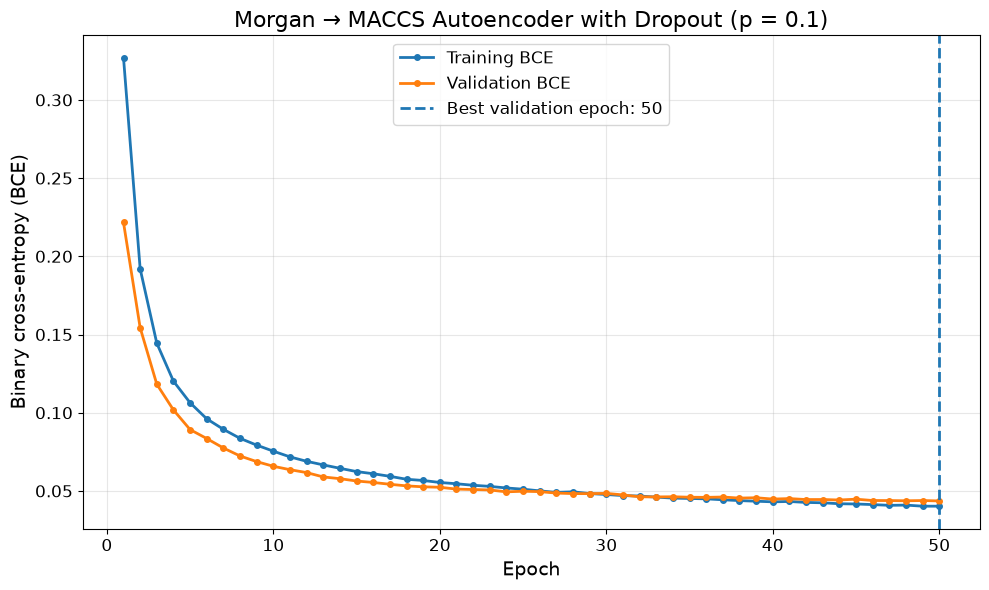

In [20]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses_morgan_to_maccs_dropout,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Training BCE"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses_morgan_to_maccs_dropout,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Validation BCE"
)

plt.axvline(
    best_epoch_morgan_to_maccs_dropout,
    linestyle="--",
    linewidth=2,
    label=f"Best validation epoch: {best_epoch_morgan_to_maccs_dropout}"
)

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Binary cross-entropy (BCE)", fontsize=14)
plt.title(
    "Morgan → MACCS Autoencoder with Dropout (p = 0.1)",
    fontsize=16
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/morgan_to_maccs_latent32_dropout01_bce_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Evaluate the Morgan → MACCS dropout model on the untouched test set

morgan_to_maccs_dropout_model.eval()

test_loss_total_dropout = 0.0
correct_bits_dropout = 0
total_bits_dropout = 0

with torch.no_grad():
    for morgan_batch, maccs_batch in test_loader_morgan_to_maccs:
        morgan_batch = morgan_batch.to(DEVICE)
        maccs_batch = maccs_batch.to(DEVICE)

        predicted_maccs, _ = morgan_to_maccs_dropout_model(morgan_batch)

        loss = criterion_morgan_to_maccs_dropout(
            predicted_maccs,
            maccs_batch
        )

        test_loss_total_dropout += loss.item() * morgan_batch.size(0)

        predicted_bits = (predicted_maccs >= 0.5).float()

        correct_bits_dropout += (
            predicted_bits == maccs_batch
        ).sum().item()

        total_bits_dropout += maccs_batch.numel()

test_bce_morgan_to_maccs_dropout = (
    test_loss_total_dropout / len(test_loader_morgan_to_maccs.dataset)
)

test_bitwise_accuracy_morgan_to_maccs_dropout = (
    correct_bits_dropout / total_bits_dropout
)

print("Morgan → MACCS dropout model")
print(f"Best validation epoch: {best_epoch_morgan_to_maccs_dropout}")
print(f"Test BCE: {test_bce_morgan_to_maccs_dropout:.6f}")
print(
    "Test MACCS bitwise reconstruction accuracy: "
    f"{test_bitwise_accuracy_morgan_to_maccs_dropout:.4%}"
)

Morgan → MACCS dropout model
Best validation epoch: 50
Test BCE: 0.041517
Test MACCS bitwise reconstruction accuracy: 98.4114%


In [22]:
from sklearn.metrics import average_precision_score
import numpy as np

per_molecule_pr_auc_morgan_to_maccs_dropout = []
per_molecule_tanimoto_morgan_to_maccs_dropout = []

morgan_to_maccs_dropout_model.eval()

with torch.no_grad():
    for morgan_batch, maccs_batch in test_loader_morgan_to_maccs:
        morgan_batch = morgan_batch.to(DEVICE)
        maccs_batch = maccs_batch.to(DEVICE)

        predicted_maccs, _ = morgan_to_maccs_dropout_model(morgan_batch)

        true_bits = maccs_batch.cpu().numpy()
        predicted_probs = predicted_maccs.cpu().numpy()

        # Per-compound PR-AUC / Average Precision
        for y_true, y_score in zip(true_bits, predicted_probs):
            if y_true.sum() > 0:
                per_molecule_pr_auc_morgan_to_maccs_dropout.append(
                    average_precision_score(y_true, y_score)
                )

        # Per-compound Tanimoto after thresholding predicted MACCS keys
        predicted_bits = (predicted_maccs >= 0.5).float()

        intersection = (predicted_bits * maccs_batch).sum(dim=1)
        union = ((predicted_bits + maccs_batch) > 0).float().sum(dim=1)

        tanimoto = intersection / torch.clamp(union, min=1)

        per_molecule_tanimoto_morgan_to_maccs_dropout.extend(
            tanimoto.cpu().numpy()
        )

per_molecule_pr_auc_morgan_to_maccs_dropout = np.array(
    per_molecule_pr_auc_morgan_to_maccs_dropout
)

per_molecule_tanimoto_morgan_to_maccs_dropout = np.array(
    per_molecule_tanimoto_morgan_to_maccs_dropout
)

print(
    f"Mean per-molecule PR-AUC: "
    f"{per_molecule_pr_auc_morgan_to_maccs_dropout.mean():.4f}"
)
print(
    f"Median per-molecule PR-AUC: "
    f"{np.median(per_molecule_pr_auc_morgan_to_maccs_dropout):.4f}"
)

print()

print(
    f"Mean per-molecule Tanimoto: "
    f"{per_molecule_tanimoto_morgan_to_maccs_dropout.mean():.4f}"
)
print(
    f"Median per-molecule Tanimoto: "
    f"{np.median(per_molecule_tanimoto_morgan_to_maccs_dropout):.4f}"
)

Mean per-molecule PR-AUC: 0.9892
Median per-molecule PR-AUC: 1.0000

Mean per-molecule Tanimoto: 0.9488
Median per-molecule Tanimoto: 1.0000


In [23]:
import pandas as pd
from pathlib import Path

results_summary_morgan_to_maccs = pd.DataFrame({
    "model": [
        "Morgan → MACCS baseline",
        "Morgan → MACCS dropout (p=0.1)"
    ],
    "latent_dim": [32, 32],
    "dropout_rate": [0.0, 0.1],
    "best_val_epoch": [
        best_epoch_morgan_to_maccs,
        best_epoch_morgan_to_maccs_dropout
    ],
    "best_val_bce": [
        best_val_bce_morgan_to_maccs,
        best_val_bce_morgan_to_maccs_dropout
    ],
    "test_bce": [
        test_bce_morgan_to_maccs,
        test_bce_morgan_to_maccs_dropout
    ],
    "test_bitwise_accuracy": [
        test_bitwise_accuracy_morgan_to_maccs,
        test_bitwise_accuracy_morgan_to_maccs_dropout
    ],
    "mean_pr_auc": [
        per_molecule_pr_auc_morgan_to_maccs.mean(),
        per_molecule_pr_auc_morgan_to_maccs_dropout.mean()
    ],
    "median_pr_auc": [
        np.median(per_molecule_pr_auc_morgan_to_maccs),
        np.median(per_molecule_pr_auc_morgan_to_maccs_dropout)
    ],
    "mean_tanimoto": [
        per_molecule_tanimoto_morgan_to_maccs.mean(),
        per_molecule_tanimoto_morgan_to_maccs_dropout.mean()
    ],
    "median_tanimoto": [
        np.median(per_molecule_tanimoto_morgan_to_maccs),
        np.median(per_molecule_tanimoto_morgan_to_maccs_dropout)
    ]
})

Path("../data").mkdir(exist_ok=True)

results_summary_morgan_to_maccs.to_csv(
    "../data/morgan_to_maccs_latent32_results_summary.csv",
    index=False
)

display(results_summary_morgan_to_maccs)

print(
    "Saved: ../data/morgan_to_maccs_latent32_results_summary.csv"
)

,model,latent_dim,dropout_rate,best_val_epoch,best_val_bce,test_bce,test_bitwise_accuracy,mean_pr_auc,median_pr_auc,mean_tanimoto,median_tanimoto
0,Morgan → MACCS baseline,32,0.0,16,0.053087,0.051747,0.982659,0.987593,1.0,0.945488,1.0
1,Morgan → MACCS dropout (p=0.1),32,0.1,50,0.043607,0.041517,0.984114,0.989194,1.0,0.948803,1.0


Saved: ../data/morgan_to_maccs_latent32_results_summary.csv


In [25]:
# Morgan → MACCS with Input Masking Noise

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from pathlib import Path

MASKING_RATE = 0.05

class MorganToMACCSNoiseAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim=MORGAN_INPUT_DIM,
        latent_dim=CROSS_LATENT_DIM,
        output_dim=MACCS_OUTPUT_DIM,
        masking_rate=MASKING_RATE
    ):
        super().__init__()

        self.masking_rate = masking_rate

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim),
            nn.Sigmoid()
        )

    def add_masking_noise(self, x):
        # During training only, randomly set 5% of input entries to zero
        if self.training:
            mask = torch.rand_like(x) > self.masking_rate
            return x * mask.float()
        return x

    def forward(self, x):
        noisy_x = self.add_masking_noise(x)
        latent = self.encoder(noisy_x)
        predicted_maccs = self.decoder(latent)
        return predicted_maccs, latent


morgan_to_maccs_noise_model = (
    MorganToMACCSNoiseAutoencoder()
    .to(DEVICE)
)

criterion_morgan_to_maccs_noise = nn.BCELoss()

optimizer_morgan_to_maccs_noise = optim.Adam(
    morgan_to_maccs_noise_model.parameters(),
    lr=LEARNING_RATE
)

print(morgan_to_maccs_noise_model)

MorganToMACCSNoiseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=167, bias=True)
    (5): Sigmoid()
  )
)


In [27]:
NUM_EPOCHS = 50

train_losses_morgan_to_maccs_noise = []
val_losses_morgan_to_maccs_noise = []

best_val_bce_morgan_to_maccs_noise = float("inf")
best_epoch_morgan_to_maccs_noise = None
best_state_morgan_to_maccs_noise = None

for epoch in range(NUM_EPOCHS):
    # Training: masking noise is active
    morgan_to_maccs_noise_model.train()
    train_loss_total = 0.0

    for morgan_batch, maccs_batch in train_loader_morgan_to_maccs:
        morgan_batch = morgan_batch.to(DEVICE)
        maccs_batch = maccs_batch.to(DEVICE)

        optimizer_morgan_to_maccs_noise.zero_grad()

        predicted_maccs, _ = morgan_to_maccs_noise_model(morgan_batch)

        loss = criterion_morgan_to_maccs_noise(
            predicted_maccs,
            maccs_batch
        )

        loss.backward()
        optimizer_morgan_to_maccs_noise.step()

        train_loss_total += loss.item() * morgan_batch.size(0)

    epoch_train_bce = (
        train_loss_total / len(train_loader_morgan_to_maccs.dataset)
    )
    train_losses_morgan_to_maccs_noise.append(epoch_train_bce)

    # Validation: clean Morgan input, no masking noise
    morgan_to_maccs_noise_model.eval()
    val_loss_total = 0.0

    with torch.no_grad():
        for morgan_batch, maccs_batch in val_loader_morgan_to_maccs:
            morgan_batch = morgan_batch.to(DEVICE)
            maccs_batch = maccs_batch.to(DEVICE)

            predicted_maccs, _ = morgan_to_maccs_noise_model(morgan_batch)

            loss = criterion_morgan_to_maccs_noise(
                predicted_maccs,
                maccs_batch
            )

            val_loss_total += loss.item() * morgan_batch.size(0)

    epoch_val_bce = (
        val_loss_total / len(val_loader_morgan_to_maccs.dataset)
    )
    val_losses_morgan_to_maccs_noise.append(epoch_val_bce)

    if epoch_val_bce < best_val_bce_morgan_to_maccs_noise:
        best_val_bce_morgan_to_maccs_noise = epoch_val_bce
        best_epoch_morgan_to_maccs_noise = epoch + 1
        best_state_morgan_to_maccs_noise = copy.deepcopy(
            morgan_to_maccs_noise_model.state_dict()
        )

    print(
        f"Epoch {epoch + 1:>2}/{NUM_EPOCHS} | "
        f"Train BCE: {epoch_train_bce:.5f} | "
        f"Val BCE: {epoch_val_bce:.5f}"
    )

morgan_to_maccs_noise_model.load_state_dict(
    best_state_morgan_to_maccs_noise
)

Path("../models").mkdir(exist_ok=True)

noise_checkpoint_path = (
    "../models/morgan_to_maccs_latent32_masknoise05_best.pt"
)

torch.save(
    morgan_to_maccs_noise_model.state_dict(),
    noise_checkpoint_path
)

print("\nTraining complete.")
print(
    f"Best validation BCE: "
    f"{best_val_bce_morgan_to_maccs_noise:.6f}"
)
print(
    f"Best epoch: "
    f"{best_epoch_morgan_to_maccs_noise}"
)
print(f"Saved checkpoint: {noise_checkpoint_path}")

Epoch  1/50 | Train BCE: 0.32488 | Val BCE: 0.22271
Epoch  2/50 | Train BCE: 0.18150 | Val BCE: 0.14428
Epoch  3/50 | Train BCE: 0.12459 | Val BCE: 0.10905
Epoch  4/50 | Train BCE: 0.09901 | Val BCE: 0.09246
Epoch  5/50 | Train BCE: 0.08376 | Val BCE: 0.08147
Epoch  6/50 | Train BCE: 0.07219 | Val BCE: 0.07540
Epoch  7/50 | Train BCE: 0.06412 | Val BCE: 0.06804
Epoch  8/50 | Train BCE: 0.05720 | Val BCE: 0.06273
Epoch  9/50 | Train BCE: 0.05318 | Val BCE: 0.05974
Epoch 10/50 | Train BCE: 0.04825 | Val BCE: 0.05731
Epoch 11/50 | Train BCE: 0.04479 | Val BCE: 0.05526
Epoch 12/50 | Train BCE: 0.04116 | Val BCE: 0.05417
Epoch 13/50 | Train BCE: 0.03868 | Val BCE: 0.05396
Epoch 14/50 | Train BCE: 0.03672 | Val BCE: 0.05137
Epoch 15/50 | Train BCE: 0.03435 | Val BCE: 0.05156
Epoch 16/50 | Train BCE: 0.03287 | Val BCE: 0.05077
Epoch 17/50 | Train BCE: 0.03073 | Val BCE: 0.05045
Epoch 18/50 | Train BCE: 0.02997 | Val BCE: 0.05070
Epoch 19/50 | Train BCE: 0.02786 | Val BCE: 0.05115
Epoch 20/50 

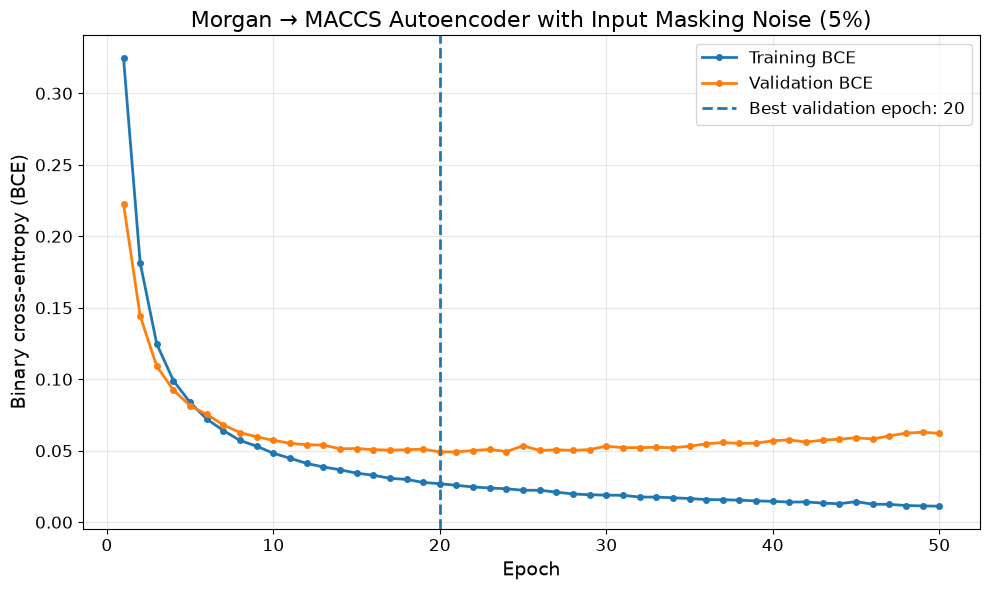

In [28]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses_morgan_to_maccs_noise,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Training BCE"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses_morgan_to_maccs_noise,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Validation BCE"
)

plt.axvline(
    best_epoch_morgan_to_maccs_noise,
    linestyle="--",
    linewidth=2,
    label=f"Best validation epoch: {best_epoch_morgan_to_maccs_noise}"
)

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Binary cross-entropy (BCE)", fontsize=14)
plt.title(
    "Morgan → MACCS Autoencoder with Input Masking Noise (5%)",
    fontsize=16
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/morgan_to_maccs_latent32_masknoise05_bce_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
import numpy as np
import pandas as pd

noise_row = pd.DataFrame({
    "model": ["Morgan → MACCS input masking noise (5%)"],
    "latent_dim": [32],
    "dropout_rate": [0.0],
    "best_val_epoch": [best_epoch_morgan_to_maccs_noise],
    "best_val_bce": [best_val_bce_morgan_to_maccs_noise],
    "test_bce": [np.nan],
    "test_bitwise_accuracy": [np.nan],
    "mean_pr_auc": [np.nan],
    "median_pr_auc": [np.nan],
    "mean_tanimoto": [np.nan],
    "median_tanimoto": [np.nan]
})

results_summary_morgan_to_maccs = pd.concat(
    [results_summary_morgan_to_maccs, noise_row],
    ignore_index=True
)

results_summary_morgan_to_maccs.to_csv(
    "../data/morgan_to_maccs_latent32_results_summary.csv",
    index=False
)

display(results_summary_morgan_to_maccs)

,model,latent_dim,dropout_rate,best_val_epoch,best_val_bce,test_bce,test_bitwise_accuracy,mean_pr_auc,median_pr_auc,mean_tanimoto,median_tanimoto
0,Morgan → MACCS baseline,32,0.0,16,0.053087,0.051747,0.982659,0.987593,1.0,0.945488,1.0
1,Morgan → MACCS dropout (p=0.1),32,0.1,50,0.043607,0.041517,0.984114,0.989194,1.0,0.948803,1.0
2,Morgan → MACCS input masking noise (5%),32,0.0,20,0.049183,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
from pathlib import Path

summary_text = """# Morgan → MACCS Cross-Representation Autoencoder

## Setup
- Input: 2048-bit Morgan fingerprints
- Target: 167-bit MACCS keys
- Latent dimension: 32
- Split: 70% train / 15% validation / 15% test
- Loss: Binary cross-entropy

## Experiments
| Model | Best validation BCE | Best epoch | Test BCE |
|---|---:|---:|---:|
| Baseline | 0.053087 | 16 | 0.051747 |
| Dropout (p=0.1) | 0.043607 | 50 | 0.041517 |
| Input masking noise (5%) | 0.049183 | 20 | Not evaluated |

## Best model
The dropout model performed best on validation and test data.

- Test bitwise accuracy: 98.4114%
- Mean per-molecule PR-AUC: 0.9892
- Mean per-molecule Tanimoto similarity: 0.9488

## Key files
- Notebook: `data/objective_3_lincs_morgan_autoencoder.ipynb`
- Results table: `data/morgan_to_maccs_latent32_results_summary.csv`
- Best dropout model: `models/morgan_to_maccs_latent32_dropout01_best.pt`
- Baseline curve: `figures/morgan_to_maccs_latent32_bce_curve.png`
- Dropout curve: `figures/morgan_to_maccs_latent32_dropout01_bce_curve.png`
- Noise curve: `figures/morgan_to_maccs_latent32_masknoise05_bce_curve.png`
"""

Path("../data/morgan_to_maccs_summary.md").write_text(summary_text)

print("Saved: ../data/morgan_to_maccs_summary.md")

Saved: ../data/morgan_to_maccs_summary.md
